# TESIS — Forecasting Harga 8 Komoditas dan Optimasi Menu GWO

**Versi notebook: diperbaiki dan dirapikan**

Perbaikan utama pada versi ini:
- `model_final` menjadi satu-satunya sumber model untuk forecast 30 hari dan uji residual/Ljung-Box;
- grafik *actual vs predicted* mengikuti split dan model final masing-masing komoditas;
- cell yang meminta *run ulang* manual dihapus agar alur **Run all** lebih konsisten;
- cell persiapan GWO yang duplikat dihapus;
- ekspor intermediate yang menyebabkan file ganda dihapus sehingga hanya ekspor final yang dijalankan;
- bagian akhir notebook diurutkan menjadi analisis → visualisasi → ekspor final → ringkasan.

> Catatan: perbaikan ini merapikan konsistensi kode dan alur notebook berdasarkan isi file yang diberikan. Dasar ilmiah target gizi, threshold FPR, interpolasi data, dan desain fungsi fitness GWO tetap mengikuti notebook dan perlu disesuaikan dengan BAB III tesis jika sumber/ketentuannya berbeda.


In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 17.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Library berhasil dimuat.")


Library berhasil dimuat.


In [ ]:
# ============================================================
# 2. UPLOAD DATA EXCEL
# ============================================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Baca seluruh sheet agar data harga dan TKPI dapat digunakan
excel_sheets = pd.read_excel(file_name, sheet_name=None)

print("File:", file_name)
print("Sheet yang tersedia:", list(excel_sheets.keys()))

# Sheet pertama diasumsikan sebagai sheet harga (01_Harga_Pangan)
df_raw = excel_sheets[list(excel_sheets.keys())[0]].copy()

# Cari sheet TKPI
sheet_tkpi = next(
    (s for s in excel_sheets.keys() if str(s).strip().lower() in ["02_tkpi", "tkpi"]),
    None
)

df_tkpi_raw = excel_sheets[sheet_tkpi].copy() if sheet_tkpi else None

print("\nSheet harga yang digunakan:", list(excel_sheets.keys())[0])
print("Sheet TKPI yang digunakan :", sheet_tkpi)
print("Ukuran data harga         :", df_raw.shape)

if df_tkpi_raw is not None:
    print("Ukuran data TKPI          :", df_tkpi_raw.shape)
else:
    print("PERINGATAN: Sheet 02_TKPI tidak ditemukan.")

display(df_raw.head())
if df_tkpi_raw is not None:
    display(df_tkpi_raw.head())


Saving Data Tanpa susu.xlsx to Data Tanpa susu.xlsx
File: Data Tanpa susu.xlsx
Sheet yang tersedia: ['01_Harga_Pangan', '02_TKPI', '03_Menu_PMT', '04_AKG', '05_Hasil_Forecast', '05_Evaluasi_Forecast', '06_FPR', '07_GWO', '08_Output']

Sheet harga yang digunakan: 01_Harga_Pangan
Sheet TKPI yang digunakan : 02_TKPI
Ukuran data harga         : (821, 9)
Ukuran data TKPI          : (9, 7)


,Tanggal,Beras Premium,Daging Ayam Ras,Telur Ayam Ras,Ikan Kembung,Wortel,Kentang,Buncis,Daging Sapi
0,2024-04-01,14960,37009.0,27731,33091,13010,15629,13720,117484
1,2024-04-02,14954,37044.0,27582,33082,12928,15632,13055,117707
2,2024-04-03,14938,37149.0,27365,33101,12929,15571,13131,117713
3,2024-04-04,14905,37423.0,27229,33121,13007,15562,13242,117165
4,2024-04-05,14893,37619.0,27128,33096,13048,15563,13194,117391


,Komoditas,Energi (kkal),Protein (g),Lemak (g),Karbohidrat (g),Fe (mg),Zn (mg)
0,Beras,360,6.80,0.70,78.90,0.8,1.4
1,Daging Ayam,302,18.20,25.00,0.00,2.0,0.9
2,Telur Ayam,154,12.40,10.80,0.70,3.0,3.0
3,Ikan Kembung,125,21.30,3.40,2.20,0.8,1.1
4,Wortel,41,0.93,0.24,9.58,1.0,0.3


In [ ]:
# ============================================================
# 3. CLEANING DATA - FORMAT WIDE
# ============================================================

# Bersihkan nama kolom
df_raw.columns = [str(c).strip() for c in df_raw.columns]

print("Kolom dataset harga:")
print(df_raw.columns.tolist())

# ------------------------------------------------------------
# DETEKSI KOLOM TANGGAL
# ------------------------------------------------------------
kol_tanggal = None

for c in df_raw.columns:
    nama = str(c).strip().lower()
    if nama in ["tanggal", "tgl", "date", "datetime"]:
        kol_tanggal = c
        break

if kol_tanggal is None:
    raise ValueError("Kolom Tanggal tidak ditemukan pada sheet harga.")

print("\nKolom tanggal :", kol_tanggal)

# ------------------------------------------------------------
# DAFTAR KOMODITAS KANONIS
# ------------------------------------------------------------
# Nama kanonis dipakai konsisten sampai tahap Forecast, FPR, GWO,
# dan optimasi menu.
daftar_komoditas = [
    "Beras Premium",
    "Daging Ayam Ras",
    "Telur Ayam Ras",
    "Ikan Kembung",
    "Wortel",
    "Kentang",
    "Buncis",
    "Daging Sapi"
]

# Beberapa workbook menggunakan nama yang lebih pendek.
alias_komoditas = {
    "Beras Premium": ["Beras Premium", "Beras"],
    "Daging Ayam Ras": ["Daging Ayam Ras", "Daging Ayam"],
    "Telur Ayam Ras": ["Telur Ayam Ras", "Telur Ayam"],
    "Ikan Kembung": ["Ikan Kembung"],
    "Wortel": ["Wortel"],
    "Kentang": ["Kentang"],
    "Buncis": ["Buncis"],
    "Daging Sapi": ["Daging Sapi"]
}

# Cari kolom harga yang tersedia dan buat mapping ke nama kanonis.
mapping_kolom_harga = {}
for kanonis, aliases in alias_komoditas.items():
    ditemukan = next(
        (alias for alias in aliases if alias in df_raw.columns),
        None
    )
    if ditemukan is not None:
        mapping_kolom_harga[ditemukan] = kanonis

komoditas_tersedia = list(mapping_kolom_harga.values())
komoditas_tidak_ditemukan = [
    k for k in daftar_komoditas if k not in komoditas_tersedia
]

print("\nKomoditas tersedia:", komoditas_tersedia)

if komoditas_tidak_ditemukan:
    print("Komoditas belum tersedia pada sheet harga:", komoditas_tidak_ditemukan)


# ------------------------------------------------------------
# UBAH FORMAT WIDE MENJADI LONG
# ------------------------------------------------------------
kolom_harga_asli = list(mapping_kolom_harga.keys())

df = df_raw[[kol_tanggal] + kolom_harga_asli].copy()
df = df.rename(columns=mapping_kolom_harga)

df = df.melt(
    id_vars=[kol_tanggal],
    value_vars=komoditas_tersedia,
    var_name="Komoditas",
    value_name="Harga"
)

df = df.rename(columns={kol_tanggal: "Tanggal"})

# ------------------------------------------------------------
# CLEANING
# ------------------------------------------------------------
df["Tanggal"] = pd.to_datetime(df["Tanggal"], errors="coerce")

df["Harga"] = pd.to_numeric(
    df["Harga"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("Rp", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip(),
    errors="coerce"
)

df["Komoditas"] = df["Komoditas"].astype(str).str.strip()

df = df.dropna(subset=["Tanggal", "Komoditas", "Harga"])
df = df[df["Harga"] > 0]
df = df.sort_values(["Komoditas", "Tanggal"]).reset_index(drop=True)

# Daftar final mengikuti daftar kanonis.
komoditas_list = [
    k for k in daftar_komoditas
    if k in df["Komoditas"].unique()
]

print("\n==============================================")
print("DATA BERHASIL DIUBAH KE FORMAT LONG")
print("==============================================")
print("Jumlah komoditas :", len(komoditas_list))
print("Daftar komoditas :")
for i, k in enumerate(komoditas_list, 1):
    print(f"{i}. {k}")

if len(komoditas_list) != 8:
    raise ValueError(
        f"Notebook ini mengharapkan 8 komoditas, "
        f"tetapi terdeteksi {len(komoditas_list)}. "
        "Pastikan 8 komoditas utama tersedia pada 01_Harga_Pangan."
    )

print("\nJumlah baris :", len(df))
display(df.head(10))


Kolom dataset harga:
['Tanggal', 'Beras Premium', 'Daging Ayam Ras', 'Telur Ayam Ras', 'Ikan Kembung', 'Wortel', 'Kentang', 'Buncis', 'Daging Sapi']

Kolom tanggal : Tanggal

Komoditas tersedia: ['Beras Premium', 'Daging Ayam Ras', 'Telur Ayam Ras', 'Ikan Kembung', 'Wortel', 'Kentang', 'Buncis', 'Daging Sapi']

DATA BERHASIL DIUBAH KE FORMAT LONG
Jumlah komoditas : 8
Daftar komoditas :
1. Beras Premium
2. Daging Ayam Ras
3. Telur Ayam Ras
4. Ikan Kembung
5. Wortel
6. Kentang
7. Buncis
8. Daging Sapi

Jumlah baris : 6568


,Tanggal,Komoditas,Harga
0,2024-04-01,Beras Premium,14960.0
1,2024-04-02,Beras Premium,14954.0
2,2024-04-03,Beras Premium,14938.0
3,2024-04-04,Beras Premium,14905.0
4,2024-04-05,Beras Premium,14893.0
5,2024-04-06,Beras Premium,14873.0
6,2024-04-07,Beras Premium,14884.0
7,2024-04-08,Beras Premium,14889.0
8,2024-04-09,Beras Premium,14857.0
9,2024-04-10,Beras Premium,14857.0


## 2. Penyusunan Data Harian

Setiap komoditas diubah menjadi deret harga harian. Jika terdapat tanggal tanpa data, nilai diinterpolasi berdasarkan waktu dan kemudian dilakukan forward/backward fill untuk menghindari nilai kosong.


In [ ]:
# ============================================================
# 4. DATA HARIAN
# ============================================================

data_harian = {}

for kom in komoditas_list:
    s = (
        df[df["Komoditas"] == kom]
        .set_index("Tanggal")["Harga"]
        .sort_index()
        .resample("D")
        .mean()
    )

    s = s.interpolate(method="time").ffill().bfill()
    data_harian[kom] = s

    print(
        f"{kom}: {len(s)} data | "
        f"{s.index.min().date()} s.d. {s.index.max().date()}"
    )

df_harian = pd.concat(data_harian, axis=1)
df_harian.index.name = "Tanggal"

print("\nUkuran data harian:", df_harian.shape)
display(df_harian.head())
display(df_harian.tail())


Beras Premium: 821 data | 2024-04-01 s.d. 2026-06-30
Daging Ayam Ras: 821 data | 2024-04-01 s.d. 2026-06-30
Telur Ayam Ras: 821 data | 2024-04-01 s.d. 2026-06-30
Ikan Kembung: 821 data | 2024-04-01 s.d. 2026-06-30
Wortel: 821 data | 2024-04-01 s.d. 2026-06-30
Kentang: 821 data | 2024-04-01 s.d. 2026-06-30
Buncis: 821 data | 2024-04-01 s.d. 2026-06-30
Daging Sapi: 821 data | 2024-04-01 s.d. 2026-06-30

Ukuran data harian: (821, 8)


,Beras Premium,Daging Ayam Ras,Telur Ayam Ras,Ikan Kembung,Wortel,Kentang,Buncis,Daging Sapi
Tanggal,,,,,,,,
2024-04-01,14960.0,37009.0,27731.0,33091.0,13010.0,15629.0,13720.0,117484.0
2024-04-02,14954.0,37044.0,27582.0,33082.0,12928.0,15632.0,13055.0,117707.0
2024-04-03,14938.0,37149.0,27365.0,33101.0,12929.0,15571.0,13131.0,117713.0
2024-04-04,14905.0,37423.0,27229.0,33121.0,13007.0,15562.0,13242.0,117165.0
2024-04-05,14893.0,37619.0,27128.0,33096.0,13048.0,15563.0,13194.0,117391.0


,Beras Premium,Daging Ayam Ras,Telur Ayam Ras,Ikan Kembung,Wortel,Kentang,Buncis,Daging Sapi
Tanggal,,,,,,,,
2026-06-26,14974.0,32013.0,24471.0,35490.0,14876.0,15316.0,10252.0,125474.0
2026-06-27,14979.0,31931.0,24421.0,35452.0,14806.0,15251.0,10230.0,125491.0
2026-06-28,14975.0,31821.0,24229.0,35467.0,14788.0,15233.0,10186.0,125491.0
2026-06-29,14979.0,31455.0,23682.0,35490.0,14605.0,15197.0,9798.0,125359.0
2026-06-30,14968.0,31238.0,23278.0,35519.0,14625.0,15173.0,9672.0,125359.0


In [ ]:
# ============================================================
# 5. STATISTIK DESKRIPTIF
# ============================================================

statistik = df_harian.describe().T
statistik["Jumlah Data"] = df_harian.count()
statistik = statistik[["Jumlah Data", "mean", "std", "min", "max"]]

display(statistik)


,Jumlah Data,mean,std,min,max
Beras Premium,821,14625.473812,327.356565,14135.00,15197.0
Daging Ayam Ras,821,34446.690158,2622.839159,36.62,42224.0
Telur Ayam Ras,821,26961.797808,1360.918244,23278.00,29842.0
Ikan Kembung,821,33822.294762,941.395256,32624.00,36212.0
Wortel,821,12561.953715,1573.706341,9972.00,16238.0
Kentang,821,15974.936663,1262.489220,14535.00,19682.0
Buncis,821,11694.735688,1453.857384,9266.00,16308.0
Daging Sapi,821,119433.417783,2206.943168,116884.00,126165.0


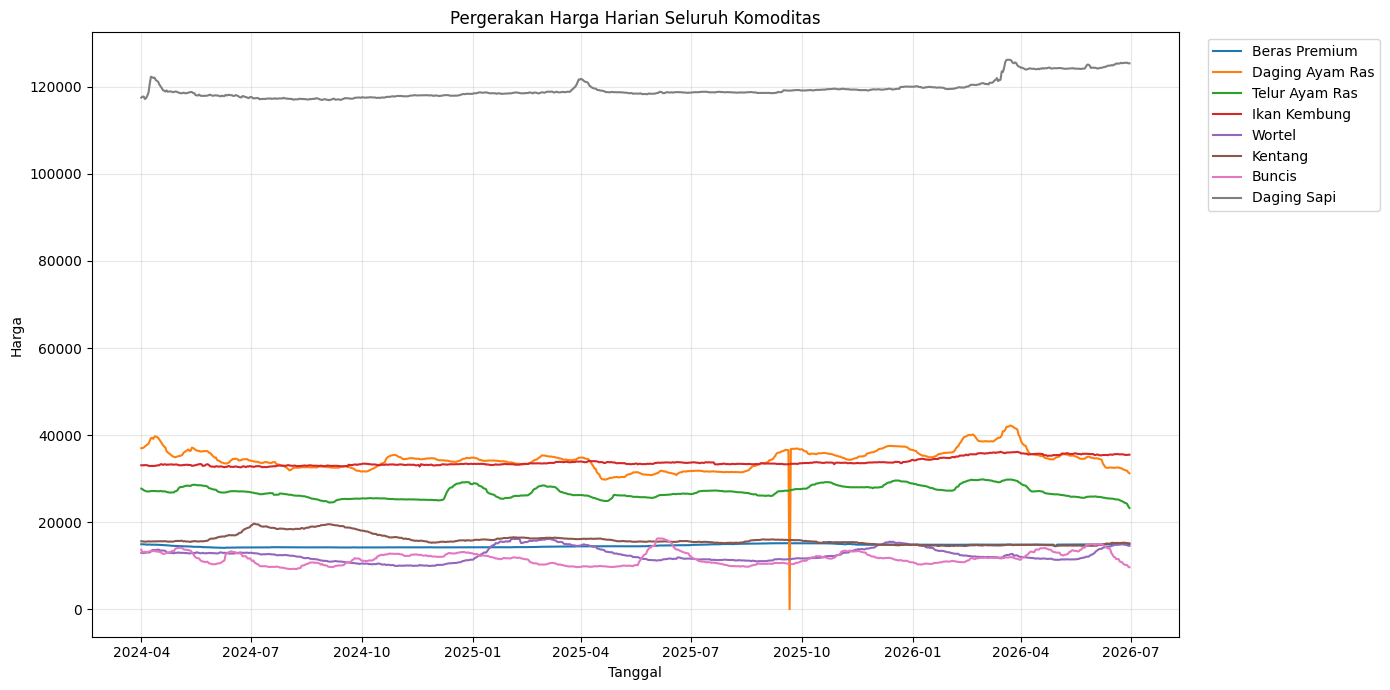

In [ ]:
# ============================================================
# 6. GRAFIK HARGA SELURUH KOMODITAS
# ============================================================

plt.figure(figsize=(14, 7))

for kom in komoditas_list:
    plt.plot(df_harian.index, df_harian[kom], label=kom)

plt.title("Pergerakan Harga Harian Seluruh Komoditas")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Uji Augmented Dickey-Fuller (ADF)

Uji ADF digunakan untuk mengetahui stasioneritas masing-masing deret harga.


In [ ]:
# ============================================================
# 7. UJI ADF
# ============================================================

def hasil_adf(series):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    return {
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags": result[2],
        "Observations": result[3],
        "Stasioner (alpha 5%)": "Ya" if result[1] < 0.05 else "Tidak"
    }

hasil_adf_tabel = pd.DataFrame({
    kom: hasil_adf(df_harian[kom]) for kom in komoditas_list
}).T

display(hasil_adf_tabel)


,ADF Statistic,p-value,Lags,Observations,Stasioner (alpha 5%)
Beras Premium,-1.314449,0.622536,19,801,Tidak
Daging Ayam Ras,-2.893947,0.046056,6,814,Ya
Telur Ayam Ras,-2.571514,0.099029,8,812,Tidak
Ikan Kembung,-0.23772,0.933874,2,818,Tidak
Wortel,-3.360105,0.012396,14,806,Ya
Kentang,-1.832187,0.364603,9,811,Tidak
Buncis,-4.812525,0.000051,7,813,Ya
Daging Sapi,-0.69338,0.848457,5,815,Tidak


## 5. Pembagian Training dan Testing

Pembagian dilakukan secara kronologis. Default menggunakan 80% data awal untuk training dan 20% data terakhir untuk testing.


In [ ]:
# ============================================================
# 8. TRAINING - TESTING
# ============================================================

TEST_SIZE = 0.20
train_test = {}

for kom in komoditas_list:
    s = df_harian[kom].dropna()
    split_idx = int(len(s) * (1 - TEST_SIZE))

    train_test[kom] = {
        "train": s.iloc[:split_idx],
        "test": s.iloc[split_idx:]
    }

    print(f"{kom}: train={len(s.iloc[:split_idx])}, test={len(s.iloc[split_idx:])}")


Beras Premium: train=656, test=165
Daging Ayam Ras: train=656, test=165
Telur Ayam Ras: train=656, test=165
Ikan Kembung: train=656, test=165
Wortel: train=656, test=165
Kentang: train=656, test=165
Buncis: train=656, test=165
Daging Sapi: train=656, test=165


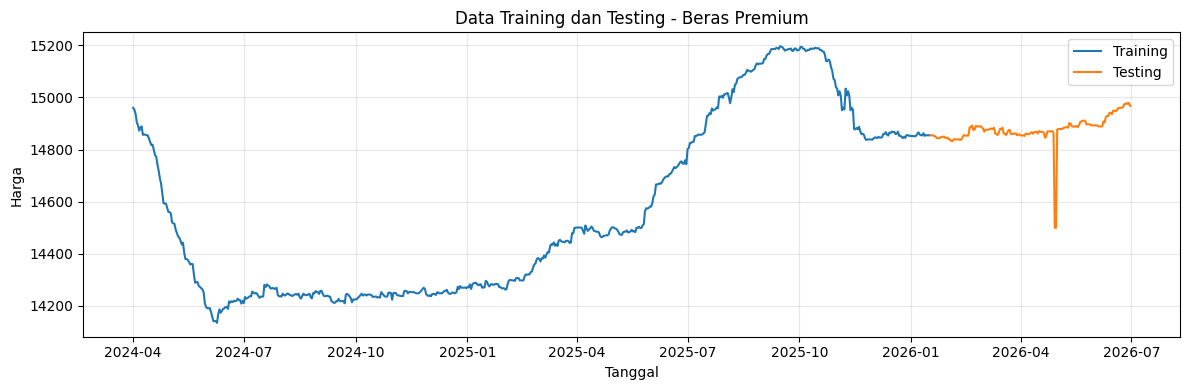

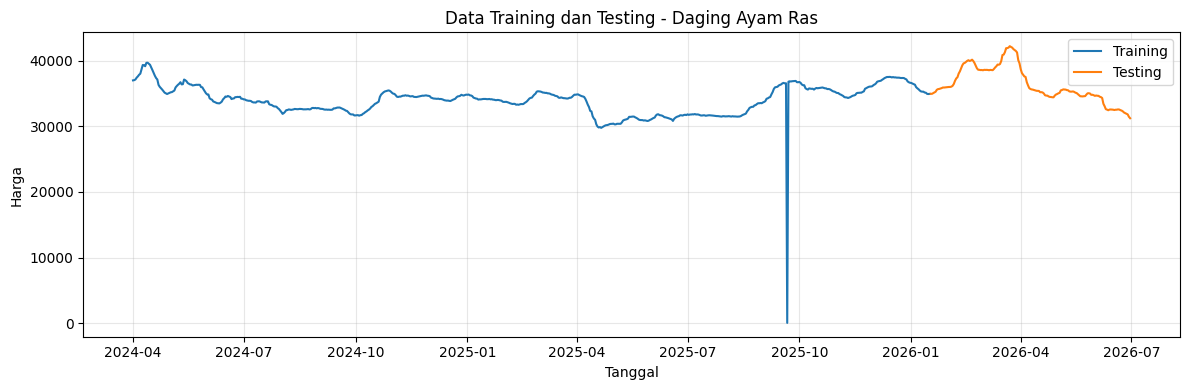

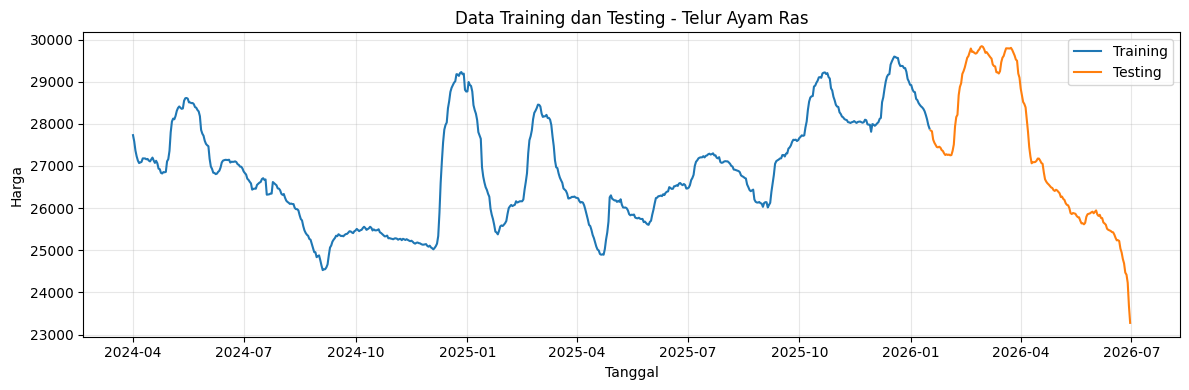

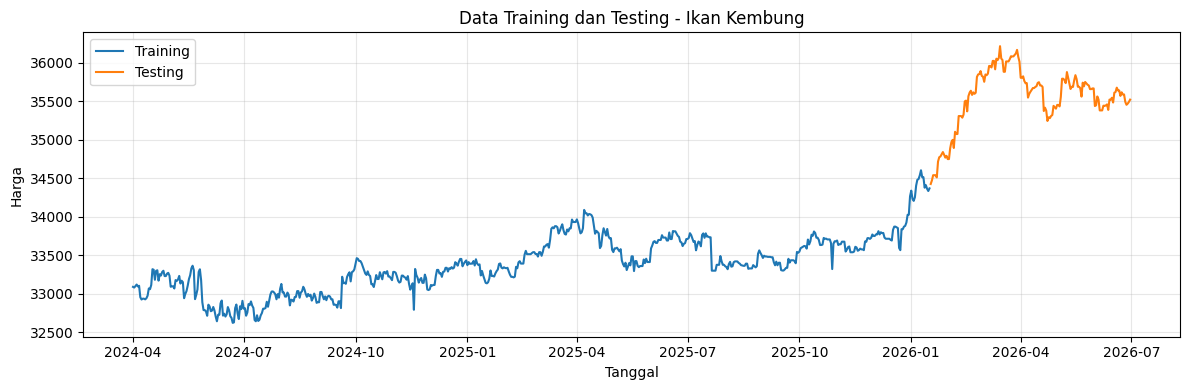

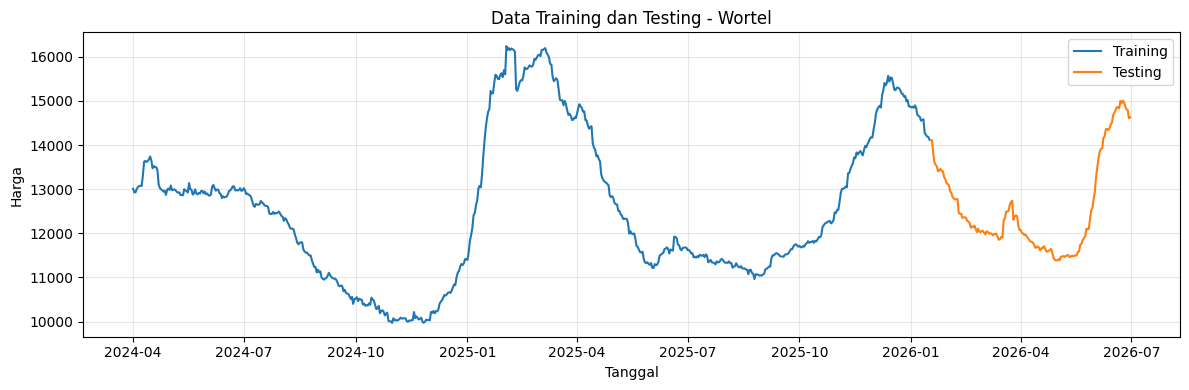

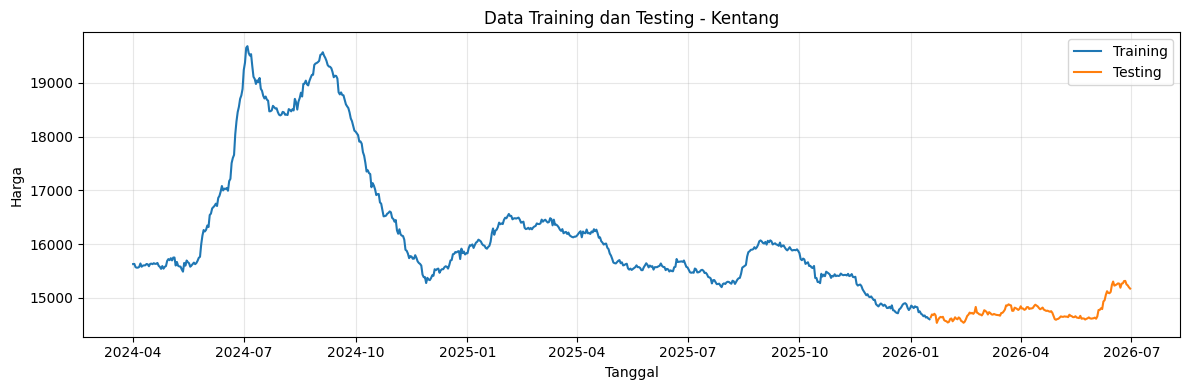

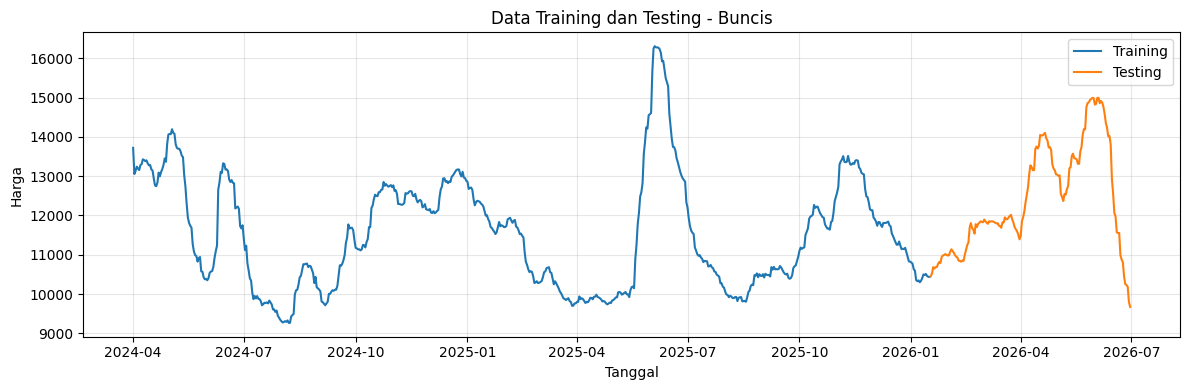

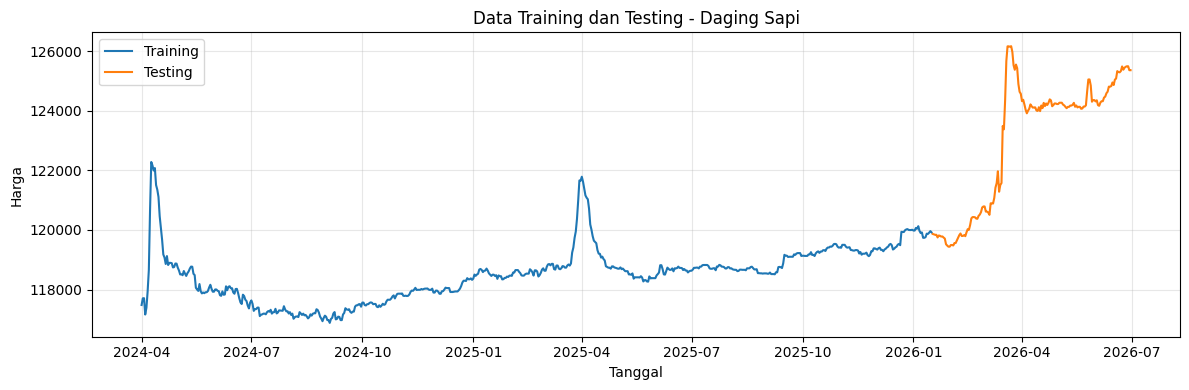

In [ ]:
# ============================================================
# 9. GRAFIK TRAINING DAN TESTING
# ============================================================

for kom in komoditas_list:
    train = train_test[kom]["train"]
    test = train_test[kom]["test"]

    plt.figure(figsize=(12, 4))
    plt.plot(train.index, train.values, label="Training")
    plt.plot(test.index, test.values, label="Testing")
    plt.title(f"Data Training dan Testing - {kom}")
    plt.xlabel("Tanggal")
    plt.ylabel("Harga")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 6. Pemilihan Model ARIMA

Beberapa kombinasi `(p,d,q)` diuji dan model dengan AIC terkecil dipilih.


In [ ]:
# ============================================================
# 10. PEMILIHAN ARIMA TERBAIK
# ============================================================

def cari_arima_terbaik(train, p_max=2, d_max=2, q_max=2):
    hasil = []

    for p in range(p_max + 1):
        for d in range(d_max + 1):
            for q in range(q_max + 1):
                try:
                    fit = ARIMA(
                        train,
                        order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit()

                    if np.isfinite(fit.aic):
                        hasil.append({"order": (p, d, q), "AIC": fit.aic})
                except Exception:
                    pass

    if not hasil:
        raise ValueError("Tidak ada model ARIMA yang berhasil.")

    tabel = pd.DataFrame(hasil).sort_values("AIC").reset_index(drop=True)
    return tabel.loc[0, "order"], tabel

model_terbaik = {}
tabel_aic = {}

for kom in komoditas_list:
    order, tabel = cari_arima_terbaik(train_test[kom]["train"])
    model_terbaik[kom] = order
    tabel_aic[kom] = tabel

    print(f"{kom} -> Model terbaik: {order}, AIC: {tabel.loc[0, 'AIC']:.4f}")


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Beras Premium -> Model terbaik: (0, 2, 2), AIC: 5030.1105
Daging Ayam Ras -> Model terbaik: (0, 1, 2), AIC: 11461.8531
Telur Ayam Ras -> Model terbaik: (1, 2, 2), AIC: 7624.0478


/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Ikan Kembung -> Model terbaik: (1, 2, 2), AIC: 7456.7771
Wortel -> Model terbaik: (0, 2, 2), AIC: 7718.4750
Kentang -> Model terbaik: (1, 1, 2), AIC: 7248.7008
Buncis -> Model terbaik: (2, 0, 2), AIC: 8270.1139
Daging Sapi -> Model terbaik: (2, 2, 2), AIC: 8206.2464


In [ ]:
# ============================================================
# 11. EVALUASI MAE, RMSE, MAPE
# ============================================================

hasil_evaluasi = []
prediksi_testing = {}

for kom in komoditas_list:
    train = train_test[kom]["train"]
    test = train_test[kom]["test"]
    order = model_terbaik[kom]

    fit = ARIMA(
        train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    pred = fit.forecast(steps=len(test))
    pred.index = test.index
    prediksi_testing[kom] = pred

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    mask = test != 0
    mape = (
        np.mean(np.abs((test[mask] - pred[mask]) / test[mask])) * 100
        if mask.any() else np.nan
    )

    hasil_evaluasi.append({
        "Komoditas": kom,
        "Model ARIMA": str(order),
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

evaluasi_forecast = pd.DataFrame(hasil_evaluasi)
display(evaluasi_forecast)


,Komoditas,Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,"(0, 2, 2)",50.002925,70.952184,0.336137
1,Daging Ayam Ras,"(0, 1, 2)",2159.702063,2922.912117,5.721980
2,Telur Ayam Ras,"(1, 2, 2)",1526.994531,1738.738109,5.626746
3,Ikan Kembung,"(1, 2, 2)",1013.852797,1076.466983,2.841445
4,Wortel,"(0, 2, 2)",2786.534172,3932.267052,21.291775
5,Kentang,"(1, 1, 2)",276.303801,340.090887,1.854377
6,Buncis,"(2, 0, 2)",1147.578908,1592.459774,8.556716
7,Daging Sapi,"(2, 2, 2)",2955.180158,3515.863642,2.375321


## 7. Perbandingan Skenario Training–Testing

Sesuai arahan pembimbing, performa forecasting dibandingkan pada empat skenario pembagian data secara kronologis: 60:40, 70:30, 80:20, dan 90:10. Evaluasi menggunakan MAE, RMSE, dan MAPE. Tahap ini digunakan untuk membandingkan performa model; model forecasting final tetap ditetapkan setelah hasil perbandingan dan validasi ditinjau.


In [ ]:
# ============================================================
# 12. PERBANDINGAN TRAINING - TESTING
# 60:40, 70:30, 80:20, 90:10
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

split_skenario = {
    "60:40": 0.60,
    "70:30": 0.70,
    "80:20": 0.80,
    "90:10": 0.90
}

hasil_perbandingan = []

# Pastikan tanggal terurut
df_harian = df_harian.sort_index()

for komoditas in komoditas_list:

    data = pd.to_numeric(
        df_harian[komoditas],
        errors="coerce"
    ).dropna()

    n = len(data)

    for nama_split, proporsi_train in split_skenario.items():

        train_size = int(n * proporsi_train)

        train = data.iloc[:train_size]
        test = data.iloc[train_size:]

        if len(train) < 10 or len(test) < 1:
            continue

        try:
            model = auto_arima(
                train,
                start_p=0,
                start_q=0,
                max_p=3,
                max_q=3,
                d=None,
                seasonal=False,
                test="adf",
                stepwise=True,
                suppress_warnings=True,
                error_action="ignore"
            )

            prediksi = model.predict(n_periods=len(test))

            mae = mean_absolute_error(test, prediksi)
            rmse = np.sqrt(mean_squared_error(test, prediksi))

            test_array = np.asarray(test, dtype=float)
            pred_array = np.asarray(prediksi, dtype=float)
            mask = test_array != 0

            mape = (
                np.mean(
                    np.abs(
                        (test_array[mask] - pred_array[mask])
                        / test_array[mask]
                    )
                ) * 100
                if mask.sum() > 0 else np.nan
            )

            hasil_perbandingan.append({
                "Komoditas": komoditas,
                "Split": nama_split,
                "Training (%)": int(proporsi_train * 100),
                "Testing (%)": int((1 - proporsi_train) * 100),
                "Jumlah Training": len(train),
                "Jumlah Testing": len(test),
                "Model ARIMA": str(model.order),
                "MAE": mae,
                "RMSE": rmse,
                "MAPE (%)": mape
            })

        except Exception as e:
            print(f"Error {komoditas} - {nama_split}: {e}")

hasil_split_forecast = pd.DataFrame(hasil_perbandingan)

hasil_split_forecast[
    ["MAE", "RMSE", "MAPE (%)"]
] = hasil_split_forecast[
    ["MAE", "RMSE", "MAPE (%)"]
].round(2)

hasil_split_forecast = hasil_split_forecast.sort_values(
    ["Komoditas", "Training (%)"]
).reset_index(drop=True)

print("=" * 90)
print("HASIL PERBANDINGAN TRAINING-TESTING")
print("=" * 90)
display(hasil_split_forecast)


HASIL PERBANDINGAN TRAINING-TESTING


,Komoditas,Split,Training (%),Testing (%),Jumlah Training,Jumlah Testing,Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,60:40,60,40,492,329,"(2, 0, 2)",459.50,490.32,3.07
1,Beras Premium,70:30,70,30,574,247,"(1, 0, 3)",227.00,235.42,1.53
2,Beras Premium,80:20,80,19,656,165,"(2, 1, 1)",38.79,61.04,0.26
3,Beras Premium,90:10,90,9,738,83,"(2, 1, 1)",56.49,81.95,0.38
4,Buncis,60:40,60,40,492,329,"(2, 0, 1)",980.52,1282.04,7.90
5,Buncis,70:30,70,30,574,247,"(2, 0, 1)",1142.60,1470.24,8.87
6,Buncis,80:20,80,19,656,165,"(2, 0, 1)",1110.20,1556.58,8.28
7,Buncis,90:10,90,9,738,83,"(3, 0, 2)",970.67,1315.82,7.91
8,Daging Ayam Ras,60:40,60,40,492,329,"(3, 0, 2)",4588.11,5335.99,273.13
9,Daging Ayam Ras,70:30,70,30,574,247,"(1, 1, 2)",2438.23,3161.44,6.46


In [ ]:
display(hasil_split_forecast)

,Komoditas,Split,Training (%),Testing (%),Jumlah Training,Jumlah Testing,Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,60:40,60,40,492,329,"(2, 0, 2)",459.50,490.32,3.07
1,Beras Premium,70:30,70,30,574,247,"(1, 0, 3)",227.00,235.42,1.53
2,Beras Premium,80:20,80,19,656,165,"(2, 1, 1)",38.79,61.04,0.26
3,Beras Premium,90:10,90,9,738,83,"(2, 1, 1)",56.49,81.95,0.38
4,Buncis,60:40,60,40,492,329,"(2, 0, 1)",980.52,1282.04,7.90
5,Buncis,70:30,70,30,574,247,"(2, 0, 1)",1142.60,1470.24,8.87
6,Buncis,80:20,80,19,656,165,"(2, 0, 1)",1110.20,1556.58,8.28
7,Buncis,90:10,90,9,738,83,"(3, 0, 2)",970.67,1315.82,7.91
8,Daging Ayam Ras,60:40,60,40,492,329,"(3, 0, 2)",4588.11,5335.99,273.13
9,Daging Ayam Ras,70:30,70,30,574,247,"(1, 1, 2)",2438.23,3161.44,6.46


In [ ]:
# ============================================================
# 13. SKENARIO TERBAIK SETIAP KOMODITAS
# ============================================================

idx_terbaik = (
    hasil_split_forecast
    .groupby("Komoditas")["MAPE (%)"]
    .idxmin()
)

hasil_terbaik = (
    hasil_split_forecast.loc[idx_terbaik]
    .sort_values("Komoditas")
    .reset_index(drop=True)
)

print("=" * 90)
print("SKENARIO TRAINING-TESTING TERBAIK BERDASARKAN MAPE")
print("=" * 90)
display(hasil_terbaik)

print("\nRATA-RATA MAPE SETIAP SKENARIO")
ringkasan_split = (
    hasil_split_forecast
    .groupby("Split")[["MAE", "RMSE", "MAPE (%)"]]
    .mean()
    .reindex(["60:40", "70:30", "80:20", "90:10"])
    .round(2)
)
display(ringkasan_split)


SKENARIO TRAINING-TESTING TERBAIK BERDASARKAN MAPE


,Komoditas,Split,Training (%),Testing (%),Jumlah Training,Jumlah Testing,Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,80:20,80,19,656,165,"(2, 1, 1)",38.79,61.04,0.26
1,Buncis,60:40,60,40,492,329,"(2, 0, 1)",980.52,1282.04,7.90
2,Daging Ayam Ras,80:20,80,19,656,165,"(1, 1, 1)",2185.77,2970.10,5.78
3,Daging Sapi,90:10,90,9,738,83,"(2, 1, 1)",328.12,500.53,0.26
4,Ikan Kembung,90:10,90,9,738,83,"(0, 1, 2)",207.71,251.09,0.59
5,Kentang,90:10,90,9,738,83,"(2, 1, 1)",185.66,246.35,1.24
6,Telur Ayam Ras,90:10,90,9,738,83,"(3, 0, 2)",951.67,1191.71,3.75
7,Wortel,70:30,70,30,574,247,"(1, 1, 1)",1167.10,1357.52,8.65



RATA-RATA MAPE SETIAP SKENARIO


,MAE,RMSE,MAPE (%)
Split,,,
60:40,1699.89,2100.54,38.67
70:30,1460.42,1818.12,5.18
80:20,1432.25,1737.76,4.62
90:10,811.51,1041.60,3.84


In [ ]:
# ============================================================
# 14. VALIDASI ROLLING FORECAST 10 DATA
# WALK-FORWARD VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import ast
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# 1. PASTIKAN HASIL TERBAIK TERSEDIA
# ============================================================

# Jika hasil_terbaik belum ada, buat dari hasil_split_forecast
try:
    hasil_terbaik
except NameError:

    hasil_terbaik = (
        hasil_split_forecast
        .sort_values(
            ["Komoditas", "MAPE (%)"]
        )
        .groupby("Komoditas")
        .first()
        .reset_index()
    )

print("=" * 80)
print("SKENARIO TERBAIK YANG DIGUNAKAN UNTUK VALIDASI")
print("=" * 80)

display(
    hasil_terbaik[
        [
            "Komoditas",
            "Split",
            "Training (%)",
            "Testing (%)",
            "Model ARIMA",
            "MAE",
            "RMSE",
            "MAPE (%)"
        ]
    ]
)

# ============================================================
# 2. PARAMETER VALIDASI
# ============================================================

HORIZON = 10

hasil_fold = []

print("\n" + "=" * 80)
print("VALIDASI ROLLING FORECAST 10 DATA")
print("=" * 80)

# ============================================================
# 3. PROSES SETIAP KOMODITAS
# ============================================================

for _, row in hasil_terbaik.iterrows():

    komoditas = row["Komoditas"]
    split = row["Split"]

    # Model ARIMA dari hasil sebelumnya
    order = ast.literal_eval(str(row["Model ARIMA"]))

    print("\n" + "-" * 80)
    print(f"Komoditas : {komoditas}")
    print(f"Split     : {split}")
    print(f"ARIMA     : {order}")

    # --------------------------------------------------------
    # Ambil data harga harian
    # --------------------------------------------------------

    data_komoditas = (
        df_harian[komoditas]
        .dropna()
        .astype(float)
        .reset_index(drop=True)
    )

    n = len(data_komoditas)

    print(f"Jumlah data: {n}")

    # --------------------------------------------------------
    # Tentukan training awal berdasarkan split terbaik
    # --------------------------------------------------------

    training_persen = int(
        split.split(":")[0]
    )

    initial_train = int(
        n * training_persen / 100
    )

    print(
        f"Training awal: {initial_train} data"
    )

    # --------------------------------------------------------
    # Rolling forecast
    # --------------------------------------------------------

    train_end = initial_train
    fold = 1

    while train_end + HORIZON <= n:

        # Data training
        train_data = data_komoditas.iloc[
            :train_end
        ]

        # 10 data aktual berikutnya
        test_data = data_komoditas.iloc[
            train_end:train_end + HORIZON
        ]

        try:

            # ------------------------------------------------
            # Bentuk model ARIMA
            # ------------------------------------------------

            model = ARIMA(
                train_data,
                order=order
            )

            model_fit = model.fit()

            # ------------------------------------------------
            # Forecast 10 data ke depan
            # ------------------------------------------------

            forecast = model_fit.forecast(
                steps=HORIZON
            )

            actual = np.array(test_data)
            forecast = np.array(forecast)

            # ------------------------------------------------
            # Hitung MAE
            # ------------------------------------------------

            mae = mean_absolute_error(
                actual,
                forecast
            )

            # ------------------------------------------------
            # Hitung RMSE
            # ------------------------------------------------

            rmse = np.sqrt(
                mean_squared_error(
                    actual,
                    forecast
                )
            )

            # ------------------------------------------------
            # Hitung MAPE
            # ------------------------------------------------

            mask = actual != 0

            if mask.sum() > 0:

                mape = (
                    np.mean(
                        np.abs(
                            (
                                actual[mask]
                                - forecast[mask]
                            )
                            / actual[mask]
                        )
                    ) * 100
                )

            else:

                mape = np.nan

            # ------------------------------------------------
            # Simpan hasil
            # ------------------------------------------------

            hasil_fold.append({

                "Komoditas": komoditas,

                "Split": split,

                "Model ARIMA": str(order),

                "Fold": fold,

                "Data Training": train_end,

                "Data Testing": HORIZON,

                "MAE": mae,

                "RMSE": rmse,

                "MAPE (%)": mape
            })

            print(
                f"Fold {fold:02d} | "
                f"Training {train_end} | "
                f"Testing 10 | "
                f"MAE {mae:.2f} | "
                f"RMSE {rmse:.2f} | "
                f"MAPE {mape:.4f}%"
            )

        except Exception as e:

            print(
                f"Fold {fold:02d} gagal: {e}"
            )

        # ----------------------------------------------------
        # Geser 10 data
        # ----------------------------------------------------

        train_end += HORIZON

        fold += 1


# ============================================================
# 4. DATAFRAME HASIL FOLD
# ============================================================

validasi_fold_10 = pd.DataFrame(
    hasil_fold
)

validasi_fold_10 = validasi_fold_10.round({
    "MAE": 2,
    "RMSE": 2,
    "MAPE (%)": 4
})

print("\n" + "=" * 80)
print("HASIL VALIDASI ROLLING FORECAST 10 DATA")
print("=" * 80)

display(validasi_fold_10)

SKENARIO TERBAIK YANG DIGUNAKAN UNTUK VALIDASI


,Komoditas,Split,Training (%),Testing (%),Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,80:20,80,19,"(2, 1, 1)",38.79,61.04,0.26
1,Buncis,60:40,60,40,"(2, 0, 1)",980.52,1282.04,7.90
2,Daging Ayam Ras,80:20,80,19,"(1, 1, 1)",2185.77,2970.10,5.78
3,Daging Sapi,90:10,90,9,"(2, 1, 1)",328.12,500.53,0.26
4,Ikan Kembung,90:10,90,9,"(0, 1, 2)",207.71,251.09,0.59
5,Kentang,90:10,90,9,"(2, 1, 1)",185.66,246.35,1.24
6,Telur Ayam Ras,90:10,90,9,"(3, 0, 2)",951.67,1191.71,3.75
7,Wortel,70:30,70,30,"(1, 1, 1)",1167.10,1357.52,8.65



VALIDASI ROLLING FORECAST 10 DATA

--------------------------------------------------------------------------------
Komoditas : Beras Premium
Split     : 80:20
ARIMA     : (2, 1, 1)
Jumlah data: 821
Training awal: 656 data
Fold 01 | Training 656 | Testing 10 | MAE 5.03 | RMSE 6.41 | MAPE 0.0339%
Fold 02 | Training 666 | Testing 10 | MAE 6.04 | RMSE 7.65 | MAPE 0.0407%
Fold 03 | Training 676 | Testing 10 | MAE 7.17 | RMSE 10.83 | MAPE 0.0483%
Fold 04 | Training 686 | Testing 10 | MAE 23.39 | RMSE 26.63 | MAPE 0.1571%
Fold 05 | Training 696 | Testing 10 | MAE 18.00 | RMSE 20.42 | MAPE 0.1210%
Fold 06 | Training 706 | Testing 10 | MAE 10.93 | RMSE 14.75 | MAPE 0.0736%
Fold 07 | Training 716 | Testing 10 | MAE 24.01 | RMSE 24.86 | MAPE 0.1615%
Fold 08 | Training 726 | Testing 10 | MAE 3.80 | RMSE 4.20 | MAPE 0.0256%
Fold 09 | Training 736 | Testing 10 | MAE 4.74 | RMSE 5.73 | MAPE 0.0319%
Fold 10 | Training 746 | Testing 10 | MAE 8.10 | RMSE 11.41 | MAPE 0.0545%
Fold 11 | Training 756 | T

In [ ]:
# ============================================================
# 15. RINGKASAN ROLLING FORECAST 10 DATA PER KOMODITAS
# ============================================================

ringkasan_fold_10 = (
    validasi_fold_10
    .groupby(["Komoditas", "Split", "Model ARIMA"])
    .agg(
        Rata_rata_MAE=("MAE", "mean"),
        Rata_rata_RMSE=("RMSE", "mean"),
        Rata_rata_MAPE=("MAPE (%)", "mean"),
        MAPE_Terendah=("MAPE (%)", "min"),
        MAPE_Tertinggi=("MAPE (%)", "max"),
        Jumlah_Fold=("Fold", "count")
    )
    .reset_index()
)

ringkasan_fold_10[
    [
        "Rata_rata_MAE",
        "Rata_rata_RMSE",
        "Rata_rata_MAPE",
        "MAPE_Terendah",
        "MAPE_Tertinggi"
    ]
] = ringkasan_fold_10[
    [
        "Rata_rata_MAE",
        "Rata_rata_RMSE",
        "Rata_rata_MAPE",
        "MAPE_Terendah",
        "MAPE_Tertinggi"
    ]
].round(4)

print("=" * 90)
print("RINGKASAN HASIL ROLLING FORECAST 10 DATA")
print("=" * 90)

display(ringkasan_fold_10)

In [ ]:
# ================================================================
# 16. GRAFIK RATA-RATA MAPE VALIDASI ROLLING FORECAST 10 DATA
# ================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    ringkasan_fold_10["Komoditas"],
    ringkasan_fold_10["Rata_rata_MAPE"]
)

plt.xlabel("Komoditas")
plt.ylabel("Rata-rata MAPE (%)")
plt.title(
    "Rata-rata MAPE Validasi Rolling Forecast 10 Data"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

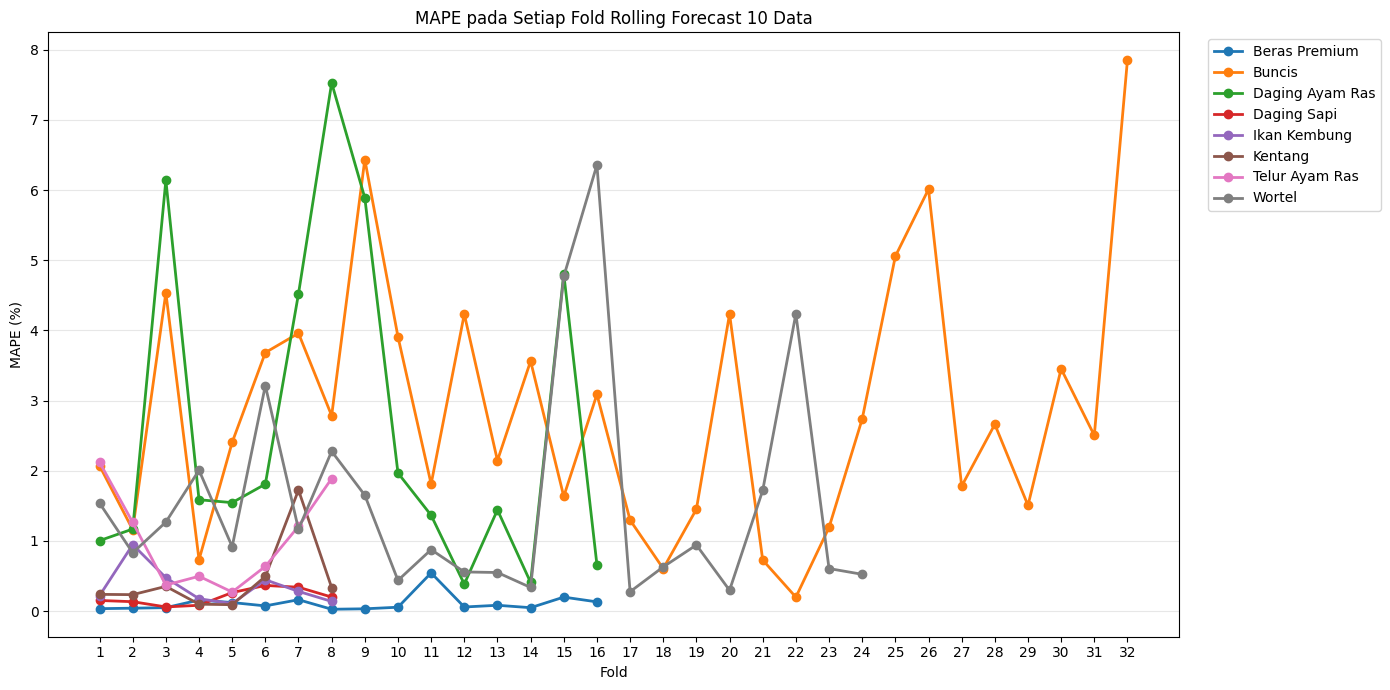

In [ ]:
# ================================================================
# 17. GRAFIK MAPE SETIAP FOLD - ROLLING FORECAST 10 DATA
# ================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Daftar komoditas
komoditas_list = validasi_fold_10["Komoditas"].unique()

# Plot MAPE setiap fold untuk setiap komoditas
for komoditas in komoditas_list:

    data_komoditas = validasi_fold_10[
        validasi_fold_10["Komoditas"] == komoditas
    ].sort_values("Fold")

    plt.plot(
        data_komoditas["Fold"],
        data_komoditas["MAPE (%)"],
        marker="o",
        linewidth=2,
        label=komoditas
    )

plt.xlabel("Fold")
plt.ylabel("MAPE (%)")
plt.title(
    "MAPE pada Setiap Fold Rolling Forecast 10 Data"
)

plt.xticks(
    sorted(validasi_fold_10["Fold"].unique())
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

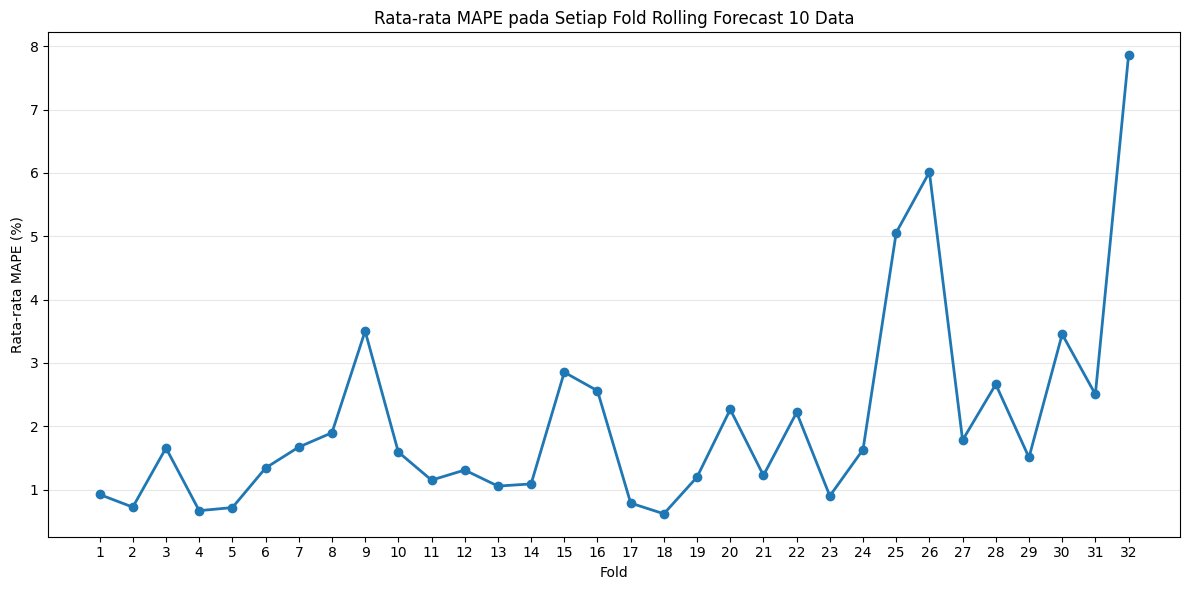

In [ ]:
# ================================================================
# 18. RATA-RATA MAPE PADA SETIAP FOLD
# ================================================================

rata_mape_fold = (
    validasi_fold_10
    .groupby("Fold")["MAPE (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    rata_mape_fold["Fold"],
    rata_mape_fold["MAPE (%)"],
    marker="o",
    linewidth=2
)

plt.xlabel("Fold")
plt.ylabel("Rata-rata MAPE (%)")
plt.title(
    "Rata-rata MAPE pada Setiap Fold Rolling Forecast 10 Data"
)

plt.xticks(
    rata_mape_fold["Fold"]
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# 19. RINGKASAN RATA-RATA ERROR ROLLING FORECAST 10 DATA
# ================================================================

ringkasan_error = (
    validasi_fold_10
    .groupby("Komoditas")
    .agg(
        Rata_rata_MAE=("MAE", "mean"),
        Rata_rata_RMSE=("RMSE", "mean"),
        Rata_rata_MAPE=("MAPE (%)", "mean"),
        MAPE_Minimum=("MAPE (%)", "min"),
        MAPE_Maksimum=("MAPE (%)", "max"),
        Std_MAPE=("MAPE (%)", "std")
    )
    .reset_index()
)

# Membulatkan hasil
kolom_angka = [
    "Rata_rata_MAE",
    "Rata_rata_RMSE",
    "Rata_rata_MAPE",
    "MAPE_Minimum",
    "MAPE_Maksimum",
    "Std_MAPE"
]

ringkasan_error[kolom_angka] = (
    ringkasan_error[kolom_angka].round(4)
)

print("=" * 90)
print("RINGKASAN RATA-RATA ERROR ROLLING FORECAST 10 DATA")
print("=" * 90)

display(ringkasan_error)

RINGKASAN RATA-RATA ERROR ROLLING FORECAST 10 DATA


,Komoditas,Rata_rata_MAE,Rata_rata_RMSE,Rata_rata_MAPE,MAPE_Minimum,MAPE_Maksimum,Std_MAPE
0,Beras Premium,16.7106,24.2238,0.1131,0.0256,0.5436,0.1266
1,Buncis,346.9647,397.1597,2.8570,0.1979,7.8574,1.8093
2,Daging Ayam Ras,981.4300,1076.0262,2.6392,0.3840,7.5283,2.3137
3,Daging Sapi,247.9775,284.9725,0.1990,0.0586,0.3650,0.1143
4,Ikan Kembung,123.6950,147.5462,0.3483,0.1060,0.9468,0.2773
5,Kentang,66.7587,78.2938,0.4456,0.0905,1.7246,0.5338
6,Telur Ayam Ras,267.9212,319.1775,1.0316,0.2708,2.1204,0.7034
7,Wortel,208.5567,242.0092,1.5825,0.2755,6.3586,1.5726


In [ ]:
# ================================================================
# 20. ANALISIS KESTABILAN ERROR
# ================================================================

ringkasan_kestabilan = (
    validasi_fold_10
    .groupby("Komoditas")
    .agg(
        MAPE_Rata_rata=("MAPE (%)", "mean"),
        MAPE_Std=("MAPE (%)", "std"),
        MAPE_Min=("MAPE (%)", "min"),
        MAPE_Max=("MAPE (%)", "max")
    )
    .reset_index()
)

# Rentang error
ringkasan_kestabilan["Rentang_MAPE"] = (
    ringkasan_kestabilan["MAPE_Max"]
    - ringkasan_kestabilan["MAPE_Min"]
)

# Kategori kestabilan berdasarkan standar deviasi MAPE
def kategori_kestabilan(std):
    if std <= 1:
        return "Sangat Stabil"
    elif std <= 2:
        return "Stabil"
    elif std <= 4:
        return "Cukup Stabil"
    else:
        return "Kurang Stabil"

ringkasan_kestabilan["Kestabilan Error"] = (
    ringkasan_kestabilan["MAPE_Std"]
    .apply(kategori_kestabilan)
)

# Pembulatan
kolom = [
    "MAPE_Rata_rata",
    "MAPE_Std",
    "MAPE_Min",
    "MAPE_Max",
    "Rentang_MAPE"
]

ringkasan_kestabilan[kolom] = (
    ringkasan_kestabilan[kolom].round(4)
)

print("=" * 100)
print("ANALISIS KESTABILAN ERROR ROLLING FORECAST 10 DATA")
print("=" * 100)

display(ringkasan_kestabilan)

ANALISIS KESTABILAN ERROR ROLLING FORECAST 10 DATA


,Komoditas,MAPE_Rata_rata,MAPE_Std,MAPE_Min,MAPE_Max,Rentang_MAPE,Kestabilan Error
0,Beras Premium,0.1131,0.1266,0.0256,0.5436,0.5180,Sangat Stabil
1,Buncis,2.8570,1.8093,0.1979,7.8574,7.6595,Stabil
2,Daging Ayam Ras,2.6392,2.3137,0.3840,7.5283,7.1443,Cukup Stabil
3,Daging Sapi,0.1990,0.1143,0.0586,0.3650,0.3064,Sangat Stabil
4,Ikan Kembung,0.3483,0.2773,0.1060,0.9468,0.8408,Sangat Stabil
5,Kentang,0.4456,0.5338,0.0905,1.7246,1.6341,Sangat Stabil
6,Telur Ayam Ras,1.0316,0.7034,0.2708,2.1204,1.8496,Sangat Stabil
7,Wortel,1.5825,1.5726,0.2755,6.3586,6.0831,Stabil


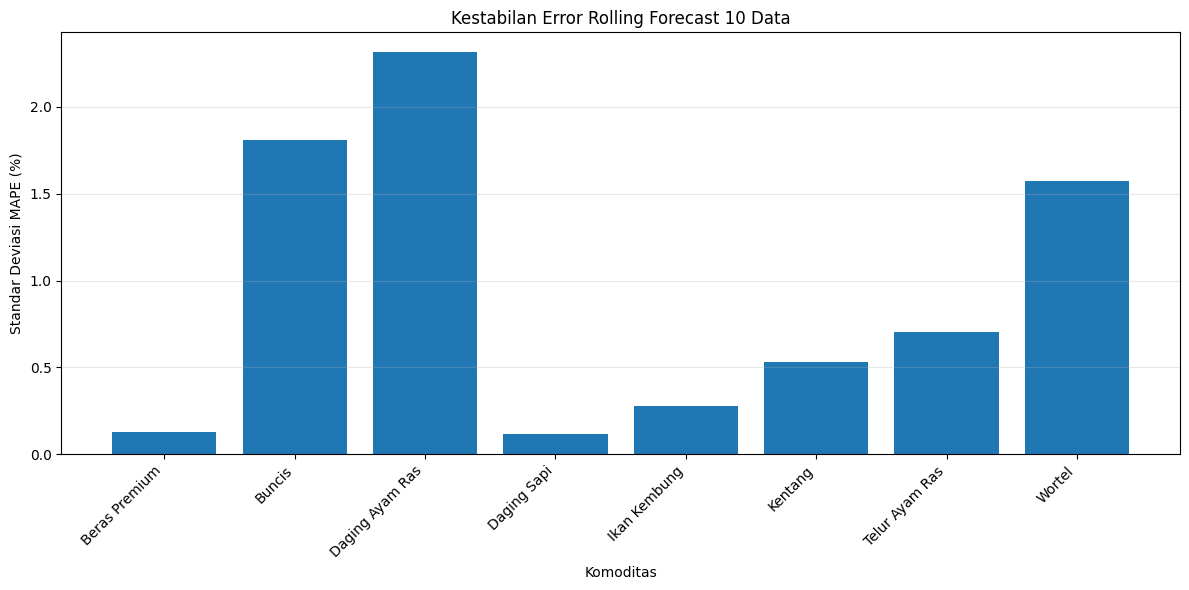

In [ ]:
# ================================================================
# 21. GRAFIK KESTABILAN ERROR
# ================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    ringkasan_kestabilan["Komoditas"],
    ringkasan_kestabilan["MAPE_Std"]
)

plt.xlabel("Komoditas")
plt.ylabel("Standar Deviasi MAPE (%)")
plt.title(
    "Kestabilan Error Rolling Forecast 10 Data"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# 22. RINGKASAN ERROR SETIAP SKENARIO
# ================================================================

ringkasan_error = (
    hasil_split_forecast
    .groupby("Split")[["MAE", "RMSE", "MAPE (%)"]]
    .mean()
    .reindex(["60:40", "70:30", "80:20", "90:10"])
    .round(4)
)

print("=" * 80)
print("RINGKASAN RATA-RATA MAE, RMSE, DAN MAPE")
print("=" * 80)

display(ringkasan_error)

RINGKASAN RATA-RATA MAE, RMSE, DAN MAPE


,MAE,RMSE,MAPE (%)
Split,,,
60:40,1699.8862,2100.5375,38.6650
70:30,1460.4188,1818.1162,5.1762
80:20,1432.2462,1737.7600,4.6225
90:10,811.5112,1041.6038,3.8388


In [ ]:
# ================================================================
# 23. PENETAPAN MODEL FORECASTING FINAL
# ================================================================

import pandas as pd
import ast

# Pastikan hasil terbaik tersedia
print("TABEL MODEL FORECASTING FINAL")
print("=" * 80)

# Ambil satu model/skenario terbaik untuk setiap komoditas
# berdasarkan MAPE terkecil
model_final = (
    hasil_terbaik
    .sort_values(["Komoditas", "MAPE (%)"])
    .groupby("Komoditas", as_index=False)
    .first()
)

# Pilih kolom yang diperlukan
model_final = model_final[
    [
        "Komoditas",
        "Split",
        "Training (%)",
        "Testing (%)",
        "Jumlah Training",
        "Jumlah Testing",
        "Model ARIMA",
        "MAE",
        "RMSE",
        "MAPE (%)"
    ]
].copy()

# Urutkan berdasarkan nama komoditas
model_final = model_final.sort_values("Komoditas").reset_index(drop=True)

# Satu sumber model final untuk seluruh tahap downstream.
# Forecast 30 hari dan residual/Ljung-Box harus menggunakan
# model yang sama dengan tabel model_final.
model_final_dict = {
    row["Komoditas"]: ast.literal_eval(str(row["Model ARIMA"]))
    for _, row in model_final.iterrows()
}

if set(model_final_dict) != set(komoditas_list):
    raise ValueError("Model final belum tersedia untuk seluruh komoditas.")

display(model_final)

TABEL MODEL FORECASTING FINAL


,Komoditas,Split,Training (%),Testing (%),Jumlah Training,Jumlah Testing,Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,80:20,80,19,656,165,"(2, 1, 1)",38.79,61.04,0.26
1,Buncis,60:40,60,40,492,329,"(2, 0, 1)",980.52,1282.04,7.90
2,Daging Ayam Ras,80:20,80,19,656,165,"(1, 1, 1)",2185.77,2970.10,5.78
3,Daging Sapi,90:10,90,9,738,83,"(2, 1, 1)",328.12,500.53,0.26
4,Ikan Kembung,90:10,90,9,738,83,"(0, 1, 2)",207.71,251.09,0.59
5,Kentang,90:10,90,9,738,83,"(2, 1, 1)",185.66,246.35,1.24
6,Telur Ayam Ras,90:10,90,9,738,83,"(3, 0, 2)",951.67,1191.71,3.75
7,Wortel,70:30,70,30,574,247,"(1, 1, 1)",1167.10,1357.52,8.65


In [ ]:
# ================================================================
# 24. RINGKASAN MODEL FORECASTING FINAL
# ================================================================

model_final_ringkas = model_final[
    [
        "Komoditas",
        "Split",
        "Model ARIMA",
        "MAE",
        "RMSE",
        "MAPE (%)"
    ]
].copy()

display(model_final_ringkas)

,Komoditas,Split,Model ARIMA,MAE,RMSE,MAPE (%)
0,Beras Premium,80:20,"(2, 1, 1)",38.79,61.04,0.26
1,Buncis,60:40,"(2, 0, 1)",980.52,1282.04,7.90
2,Daging Ayam Ras,80:20,"(1, 1, 1)",2185.77,2970.10,5.78
3,Daging Sapi,90:10,"(2, 1, 1)",328.12,500.53,0.26
4,Ikan Kembung,90:10,"(0, 1, 2)",207.71,251.09,0.59
5,Kentang,90:10,"(2, 1, 1)",185.66,246.35,1.24
6,Telur Ayam Ras,90:10,"(3, 0, 2)",951.67,1191.71,3.75
7,Wortel,70:30,"(1, 1, 1)",1167.10,1357.52,8.65


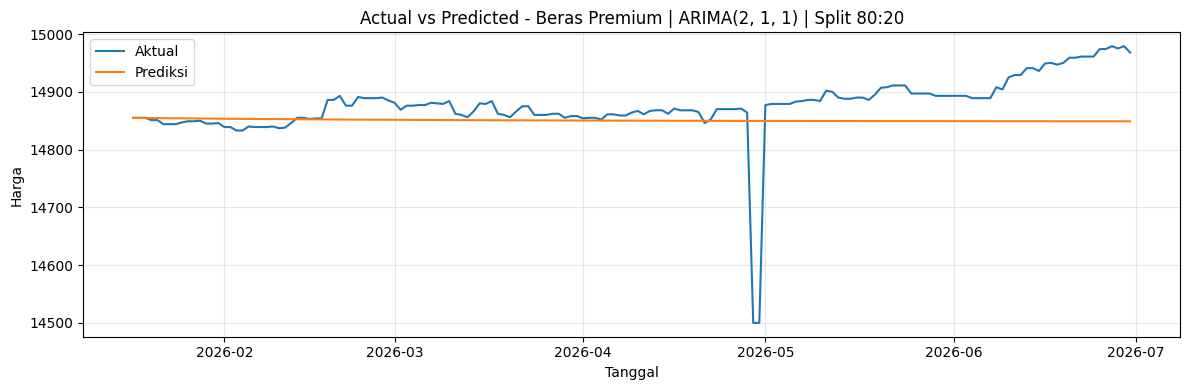

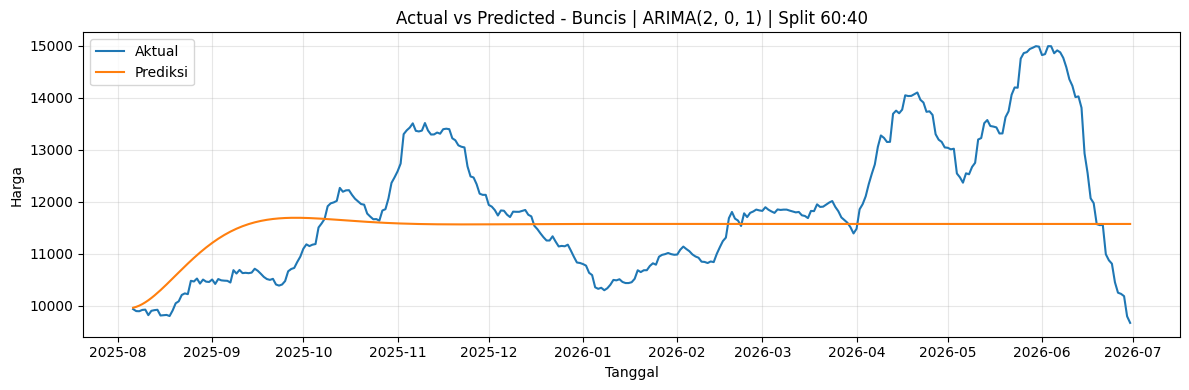

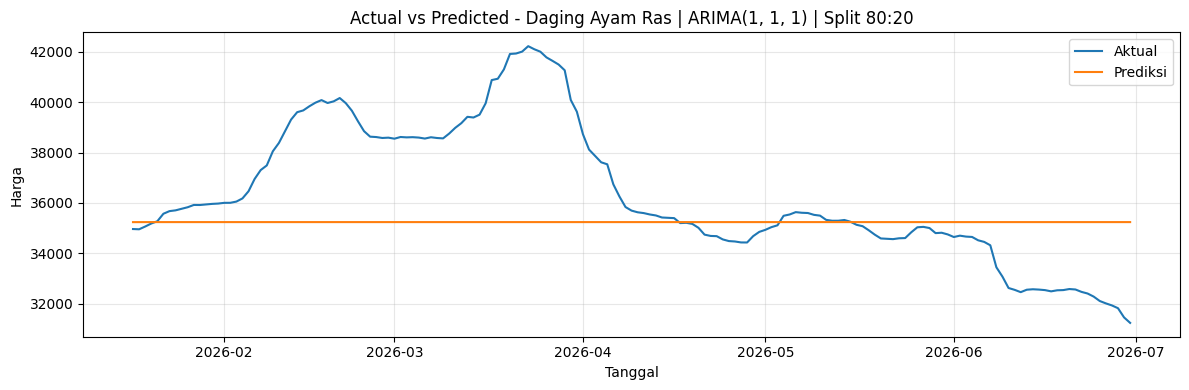

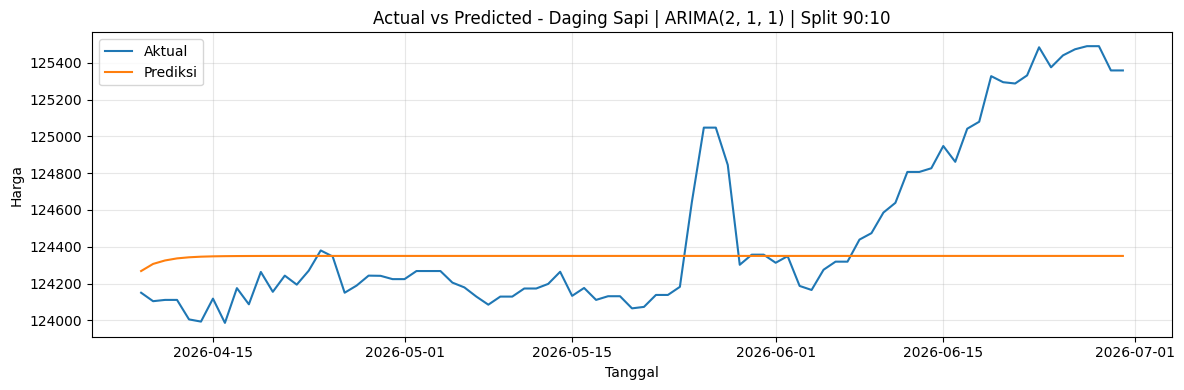

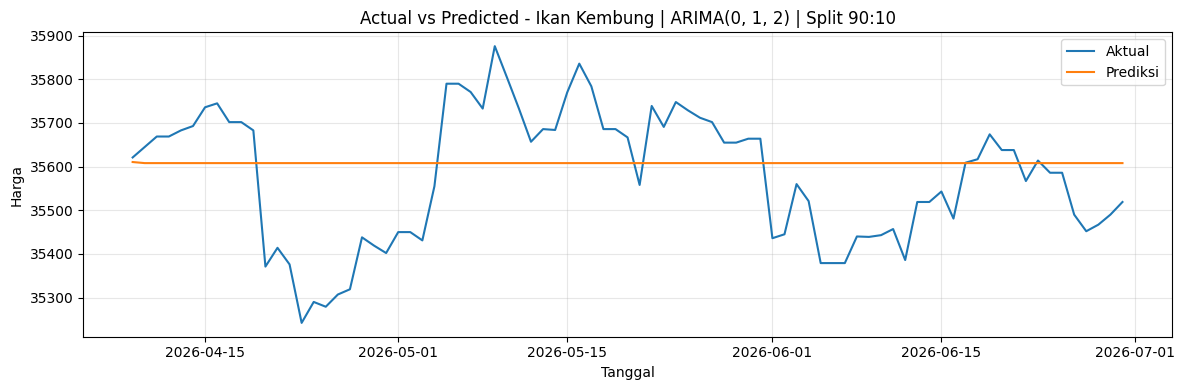

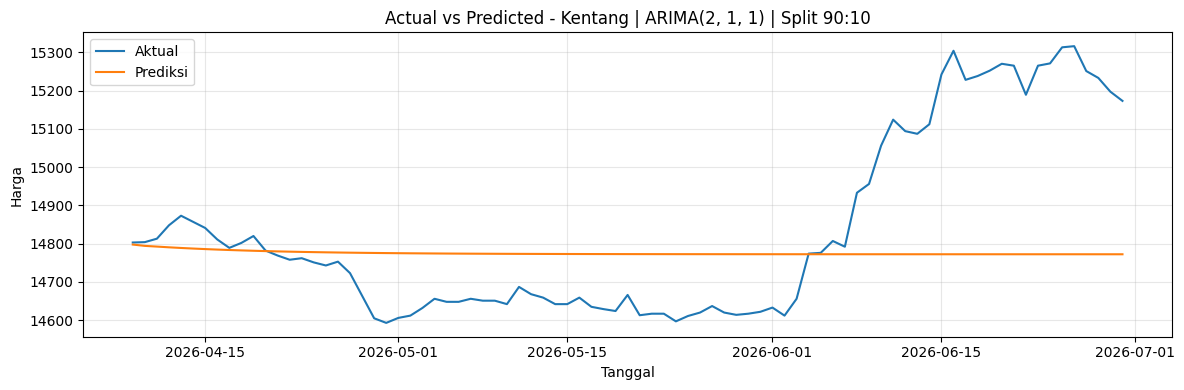

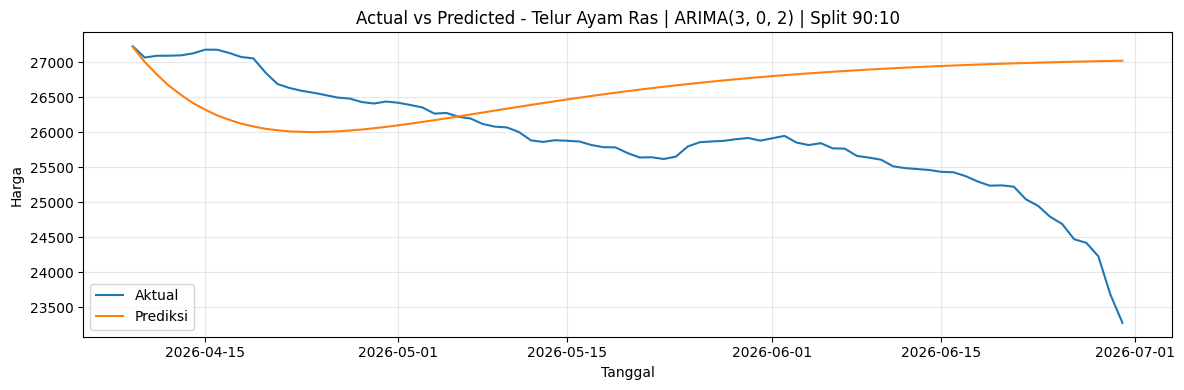

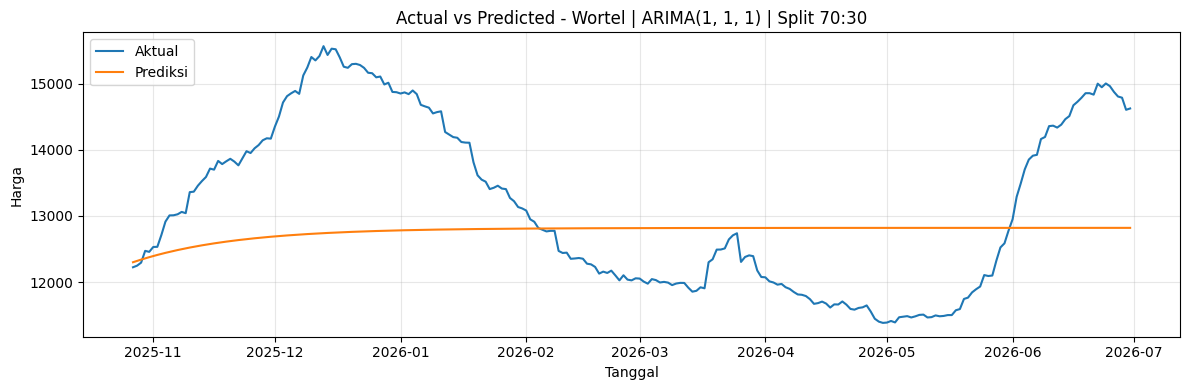

In [ ]:
# ============================================================
# 25. ACTUAL VS PREDICTED PADA SKENARIO FINAL
# ============================================================

for _, row in model_final.iterrows():
    kom = row["Komoditas"]
    training_persen = int(row["Training (%)"])
    order = model_final_dict[kom]

    series = df_harian[kom].dropna().astype(float)
    split_idx = int(len(series) * training_persen / 100)
    train = series.iloc[:split_idx]
    test = series.iloc[split_idx:]

    fit = ARIMA(
        train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    pred = fit.forecast(steps=len(test))
    pred.index = test.index

    plt.figure(figsize=(12, 4))
    plt.plot(test.index, test.values, label="Aktual")
    plt.plot(pred.index, pred.values, label="Prediksi")
    plt.title(f"Actual vs Predicted - {kom} | ARIMA{order} | Split {row['Split']}")
    plt.xlabel("Tanggal")
    plt.ylabel("Harga")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 26. Forecast 30 Hari ke Depan

Model ARIMA terbaik kemudian dilatih menggunakan seluruh data historis setiap komoditas dan digunakan untuk forecasting 30 hari ke depan.


In [ ]:
# ============================================================
# 26. FORECAST 30 HARI
# ============================================================

HORIZON = 30
forecast_series = {}
hasil_forecast = []

for kom in komoditas_list:
    series = df_harian[kom].dropna()
    order = model_final_dict[kom]

    fit = ARIMA(
        series,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    pred = fit.forecast(steps=HORIZON)

    future_dates = pd.date_range(
        start=series.index.max() + pd.Timedelta(days=1),
        periods=HORIZON,
        freq="D"
    )

    pred = pd.Series(
        np.asarray(pred, dtype=float),
        index=future_dates,
        name=kom
    )

    forecast_series[kom] = pred

    harga_awal = float(pred.iloc[0])
    harga_akhir = float(pred.iloc[-1])
    perubahan_rp = harga_akhir - harga_awal
    perubahan_persen = (
        perubahan_rp / harga_awal * 100
        if harga_awal != 0 else np.nan
    )

    hasil_forecast.append({
        "Komoditas": kom,
        "Model ARIMA": str(order),
        "Harga Awal Forecast": harga_awal,
        "Harga Akhir Forecast": harga_akhir,
        "Perubahan (Rp)": perubahan_rp,
        "Perubahan (%)": perubahan_persen
    })

forecast_df = pd.DataFrame(hasil_forecast)

print("Jumlah komoditas:", len(forecast_df))
display(forecast_df)


Jumlah komoditas: 8


,Komoditas,Model ARIMA,Harga Awal Forecast,Harga Akhir Forecast,Perubahan (Rp),Perubahan (%)
0,Beras Premium,"(2, 1, 1)",14965.252791,14968.422015,3.169224,0.021177
1,Buncis,"(2, 0, 1)",9567.204854,10823.799495,1256.594641,13.134397
2,Daging Ayam Ras,"(1, 1, 1)",31734.457549,31720.412051,-14.045498,-0.044259
3,Daging Sapi,"(2, 1, 1)",125340.373518,125328.280740,-12.092777,-0.009648
4,Ikan Kembung,"(0, 1, 2)",35513.635065,35510.599827,-3.035238,-0.008547
5,Kentang,"(2, 1, 1)",15160.362648,15027.237549,-133.125098,-0.878113
6,Telur Ayam Ras,"(3, 0, 2)",22988.609205,23624.102788,635.493583,2.764385
7,Wortel,"(1, 1, 1)",14607.939127,14331.753655,-276.185473,-1.890653


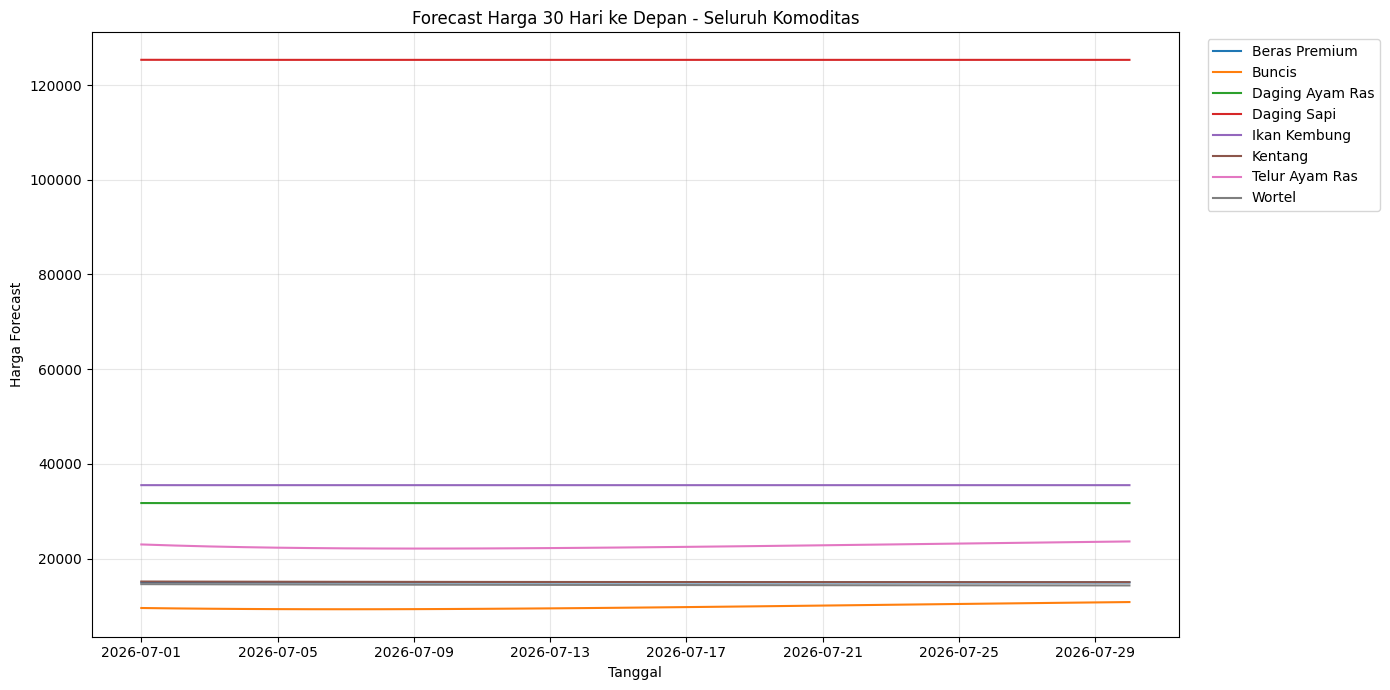

In [ ]:
# ============================================================
# 27. GRAFIK FORECAST 30 HARI
# ============================================================

plt.figure(figsize=(14, 7))

for kom in komoditas_list:
    plt.plot(
        forecast_series[kom].index,
        forecast_series[kom].values,
        label=kom
    )

plt.title("Forecast Harga 30 Hari ke Depan - Seluruh Komoditas")
plt.xlabel("Tanggal")
plt.ylabel("Harga Forecast")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 28. Residual dan Uji Ljung-Box

Residual model diperiksa untuk mengetahui apakah masih terdapat autokorelasi. Kriteria umum:
- p-value > 0,05: tidak terdapat bukti autokorelasi signifikan.
- p-value ≤ 0,05: terdapat indikasi autokorelasi.


In [ ]:
# ============================================================
# 28. RESIDUAL DAN UJI LJUNG-BOX
# ============================================================

hasil_ljung = []
residual_dict = {}

for kom in komoditas_list:
    series = df_harian[kom].dropna()
    order = model_final_dict[kom]

    fit = ARIMA(
        series,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    residual = fit.resid.dropna()
    residual_dict[kom] = residual

    lag = min(10, max(1, len(residual) // 5))

    lb = acorr_ljungbox(residual, lags=[lag], return_df=True)
    pvalue = float(lb["lb_pvalue"].iloc[0])

    hasil_ljung.append({
        "Komoditas": kom,
        "Model ARIMA": str(order),
        "Lag Ljung-Box": lag,
        "Ljung-Box Statistic": float(lb["lb_stat"].iloc[0]),
        "p-value": pvalue,
        "Kesimpulan": (
            "Tidak ada autokorelasi signifikan"
            if pvalue > 0.05 else
            "Terdapat autokorelasi"
        )
    })

ljung_box_df = pd.DataFrame(hasil_ljung)
display(ljung_box_df)


,Komoditas,Model ARIMA,Lag Ljung-Box,Ljung-Box Statistic,p-value,Kesimpulan
0,Beras Premium,"(2, 1, 1)",10,30.186346,7.985294e-04,Terdapat autokorelasi
1,Buncis,"(2, 0, 1)",10,64.026293,6.221386e-10,Terdapat autokorelasi
2,Daging Ayam Ras,"(1, 1, 1)",10,1.604996,9.985694e-01,Tidak ada autokorelasi signifikan
3,Daging Sapi,"(2, 1, 1)",10,13.780511,1.832407e-01,Tidak ada autokorelasi signifikan
4,Ikan Kembung,"(0, 1, 2)",10,0.019812,1.000000e+00,Tidak ada autokorelasi signifikan
5,Kentang,"(2, 1, 1)",10,74.409377,6.198833e-12,Terdapat autokorelasi
6,Telur Ayam Ras,"(3, 0, 2)",10,24.144980,7.224730e-03,Terdapat autokorelasi
7,Wortel,"(1, 1, 1)",10,121.236997,2.838277e-21,Terdapat autokorelasi


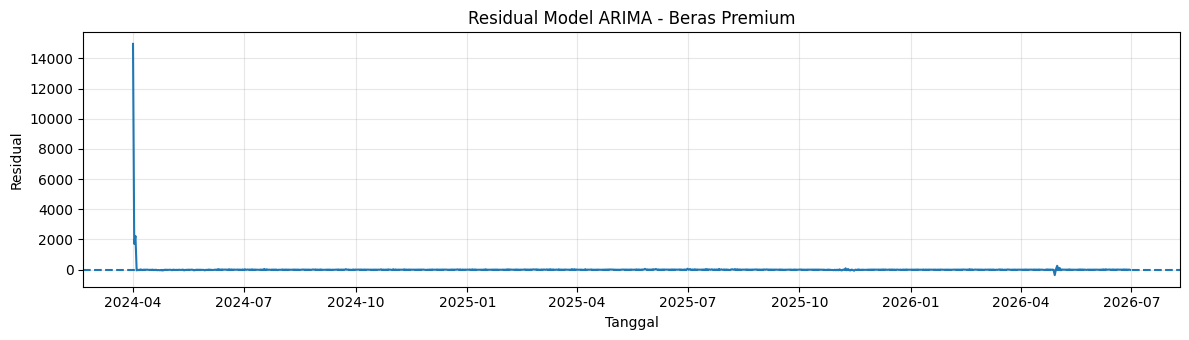

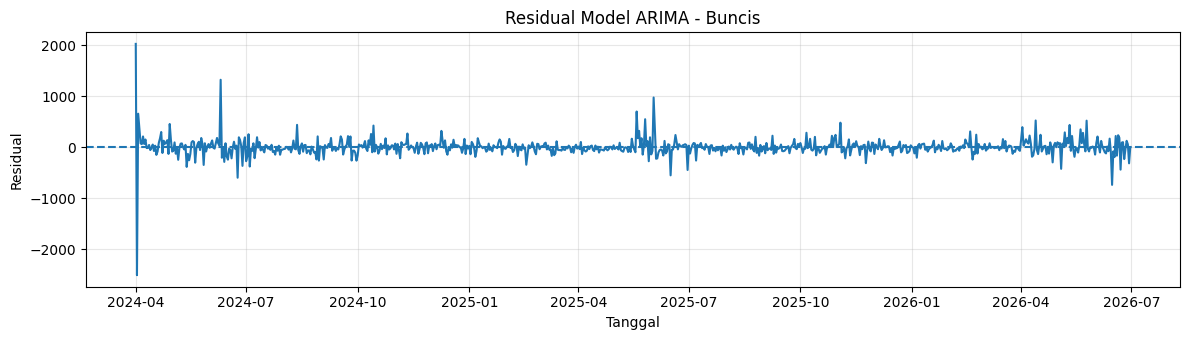

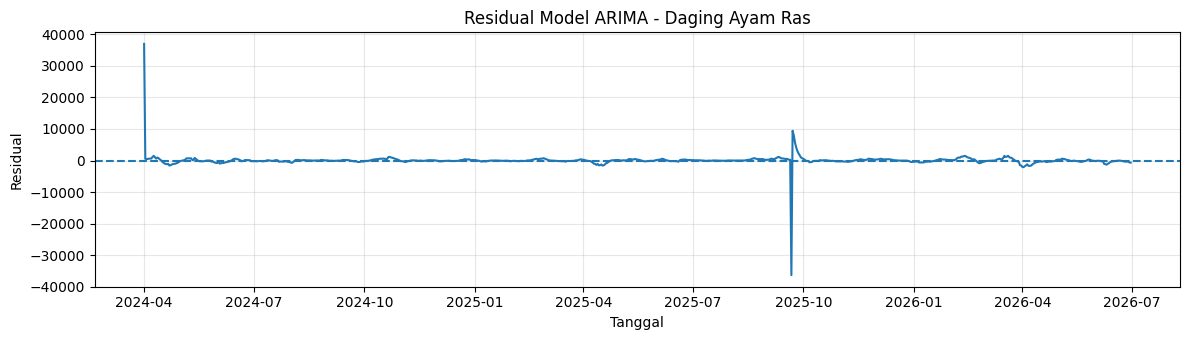

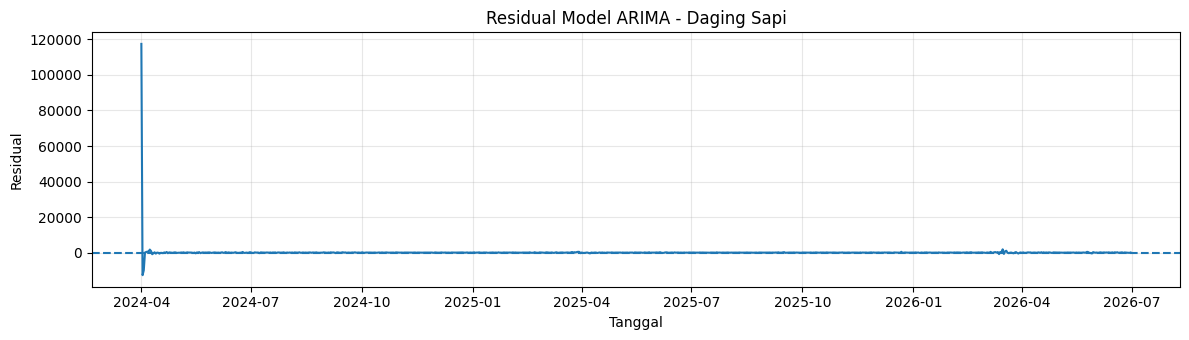

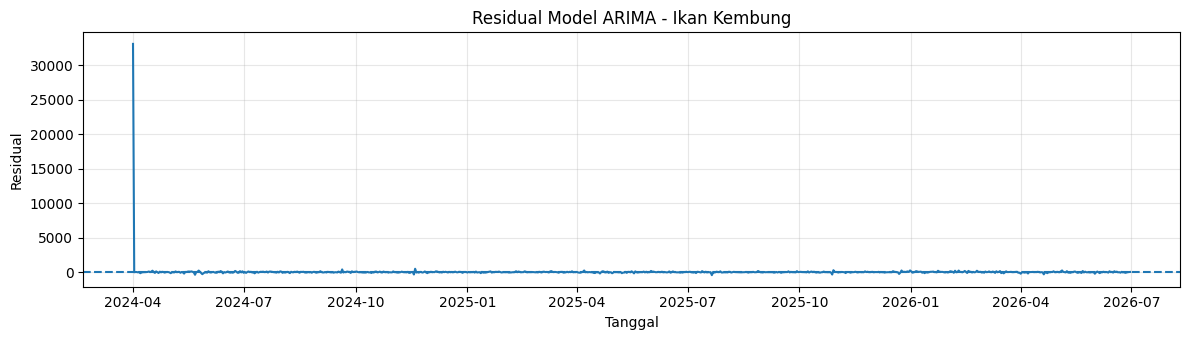

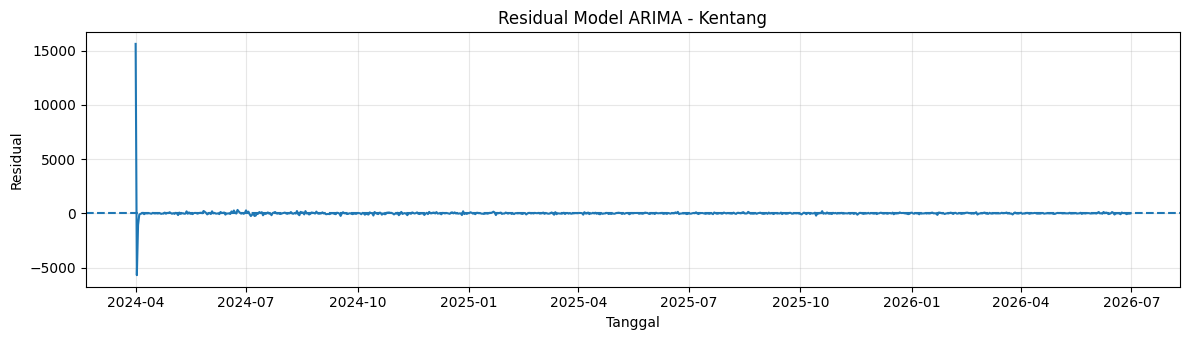

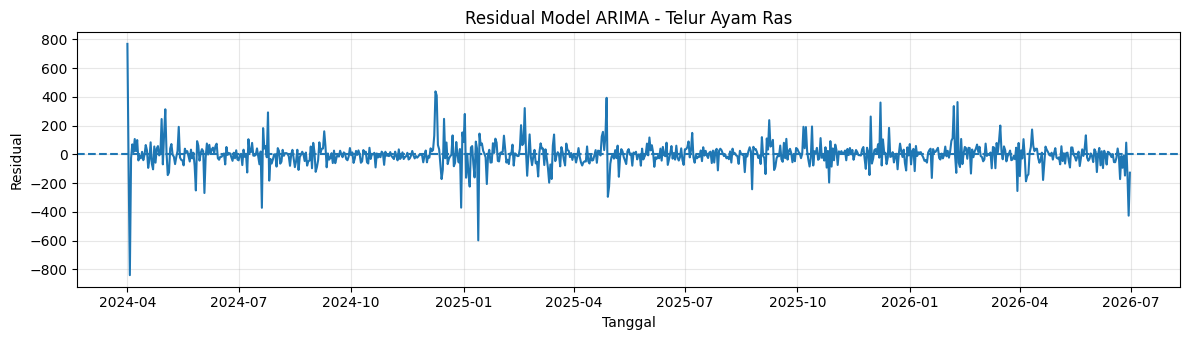

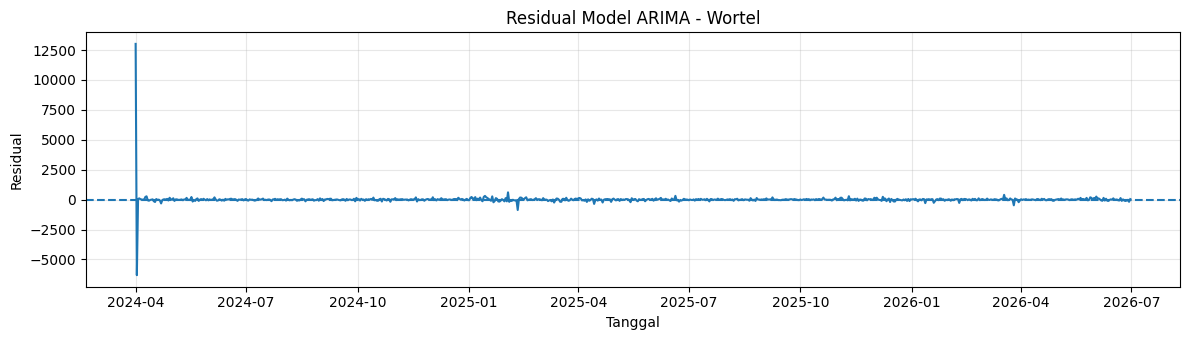

In [ ]:
# ============================================================
# 29. GRAFIK RESIDUAL
# ============================================================

for kom in komoditas_list:
    plt.figure(figsize=(12, 3.5))
    plt.plot(residual_dict[kom].index, residual_dict[kom].values)
    plt.axhline(0, linestyle="--")
    plt.title(f"Residual Model ARIMA - {kom}")
    plt.xlabel("Tanggal")
    plt.ylabel("Residual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# 30. FINANCIAL PATTERN RECOGNITION (FPR)

FPR menggunakan hasil forecasting 30 hari untuk memperoleh:
- Daily Return (%)
- Return Total (%)
- Volatilitas (%)
- Tren
- Tingkat volatilitas
- Pola FPR

Klasifikasi:
- **Volatile Uptrend**: return total naik dan volatilitas tinggi
- **Volatile Downtrend**: return total turun dan volatilitas tinggi
- **Sideways**: kondisi lainnya

Ambang dibuat eksplisit agar hasil dapat direplikasi.


In [ ]:
# ============================================================
# 31. DAILY RETURN FORECAST
# ============================================================

daily_return = pd.DataFrame(index=forecast_series[komoditas_list[0]].index)

for kom in komoditas_list:
    daily_return[kom] = forecast_series[kom].pct_change() * 100

display(daily_return.head(10))


,Beras Premium,Buncis,Daging Ayam Ras,Daging Sapi,Ikan Kembung,Kentang,Telur Ayam Ras,Wortel
2026-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-02,0.026922,-0.892060,-4.554808e-02,-0.003268,-0.008547,-0.086639,-1.002081,-0.111858
2026-07-03,-0.000528,-0.707861,1.326743e-03,-0.003301,0.000000,-0.076914,-0.841904,-0.107254
2026-07-04,-0.008190,-0.532162,-3.862781e-05,-0.001294,0.000000,-0.070342,-0.644337,-0.102833
2026-07-05,0.002048,-0.366027,1.124655e-06,-0.000858,0.000000,-0.063949,-0.518466,-0.098591
2026-07-06,0.002058,-0.210307,-3.274450e-08,-0.000413,0.000000,-0.058200,-0.359686,-0.094520
2026-07-07,-0.001106,-0.065637,9.533707e-10,-0.000240,0.000000,-0.052953,-0.263473,-0.090613
2026-07-08,-0.000381,0.067556,-2.775558e-11,-0.000125,0.000000,-0.048179,-0.138089,-0.086864
2026-07-09,0.000429,0.189044,7.993606e-13,-0.000069,0.000000,-0.043832,-0.066672,-0.083267
2026-07-10,0.000019,0.298781,-2.220446e-14,-0.000037,0.000000,-0.039876,0.030712,-0.079817


In [ ]:
# ============================================================
# 32. RINGKASAN DAILY RETURN
# ============================================================

ringkasan_return = []

for kom in komoditas_list:
    r = daily_return[kom].dropna()

    ringkasan_return.append({
        "Komoditas": kom,
        "Return Minimum (%)": r.min(),
        "Return Maksimum (%)": r.max(),
        "Rata-rata Return (%)": r.mean(),
        "Volatilitas (%)": r.std()
    })

tabel_return = pd.DataFrame(ringkasan_return)
display(tabel_return)


,Komoditas,Return Minimum (%),Return Maksimum (%),Rata-rata Return (%),Volatilitas (%)
0,Beras Premium,-0.008190,2.692205e-02,0.000730,0.005301
1,Buncis,-0.892060,8.370914e-01,0.427751,0.520082
2,Daging Ayam Ras,-0.045548,1.326743e-03,-0.001526,0.008470
3,Daging Sapi,-0.003301,-1.712408e-10,-0.000333,0.000867
4,Ikan Kembung,-0.008547,0.000000e+00,-0.000295,0.001587
5,Kentang,-0.086639,-5.983620e-03,-0.030406,0.023240
6,Telur Ayam Ras,-1.002081,3.978546e-01,0.094881,0.408285
7,Wortel,-0.111858,-3.404066e-02,-0.065795,0.023489


In [ ]:
# ============================================================
# 33. FUNGSI KLASIFIKASI FPR
# ============================================================

THRESHOLD_RETURN = 0.5     # persen
THRESHOLD_VOL = 0.02       # persen

def klasifikasi_tren(return_total):
    if return_total > THRESHOLD_RETURN:
        return "Naik"
    elif return_total < -THRESHOLD_RETURN:
        return "Turun"
    else:
        return "Stabil"

def klasifikasi_volatilitas(volatilitas):
    return "Tinggi" if volatilitas > THRESHOLD_VOL else "Rendah"

def klasifikasi_fpr(return_total, volatilitas):
    if volatilitas > THRESHOLD_VOL and return_total > THRESHOLD_RETURN:
        return "Volatile Uptrend"
    elif volatilitas > THRESHOLD_VOL and return_total < -THRESHOLD_RETURN:
        return "Volatile Downtrend"
    else:
        return "Sideways"


In [ ]:
# ============================================================
# 34. TABEL FINAL FPR
# ============================================================

hasil_fpr = []

for kom in komoditas_list:
    pred = forecast_series[kom]
    r = daily_return[kom].dropna()

    harga_awal = float(pred.iloc[0])
    harga_akhir = float(pred.iloc[-1])

    return_total = (
        (harga_akhir - harga_awal) / harga_awal * 100
        if harga_awal != 0 else np.nan
    )

    volatilitas = float(r.std())

    hasil_fpr.append({
        "Komoditas": kom,
        "Harga Awal": harga_awal,
        "Harga Akhir": harga_akhir,
        "Return Total (%)": return_total,
        "Volatilitas (%)": volatilitas,
        "Tren": klasifikasi_tren(return_total),
        "Tingkat Volatilitas": klasifikasi_volatilitas(volatilitas),
        "Pola FPR": klasifikasi_fpr(return_total, volatilitas)
    })

hasil_fpr = pd.DataFrame(hasil_fpr)

print("Jumlah komoditas:", len(hasil_fpr))
display(hasil_fpr)


Jumlah komoditas: 8


,Komoditas,Harga Awal,Harga Akhir,Return Total (%),Volatilitas (%),Tren,Tingkat Volatilitas,Pola FPR
0,Beras Premium,14965.252791,14968.422015,0.021177,0.005301,Stabil,Rendah,Sideways
1,Buncis,9567.204854,10823.799495,13.134397,0.520082,Naik,Tinggi,Volatile Uptrend
2,Daging Ayam Ras,31734.457549,31720.412051,-0.044259,0.008470,Stabil,Rendah,Sideways
3,Daging Sapi,125340.373518,125328.280740,-0.009648,0.000867,Stabil,Rendah,Sideways
4,Ikan Kembung,35513.635065,35510.599827,-0.008547,0.001587,Stabil,Rendah,Sideways
5,Kentang,15160.362648,15027.237549,-0.878113,0.023240,Turun,Tinggi,Volatile Downtrend
6,Telur Ayam Ras,22988.609205,23624.102788,2.764385,0.408285,Naik,Tinggi,Volatile Uptrend
7,Wortel,14607.939127,14331.753655,-1.890653,0.023489,Turun,Tinggi,Volatile Downtrend


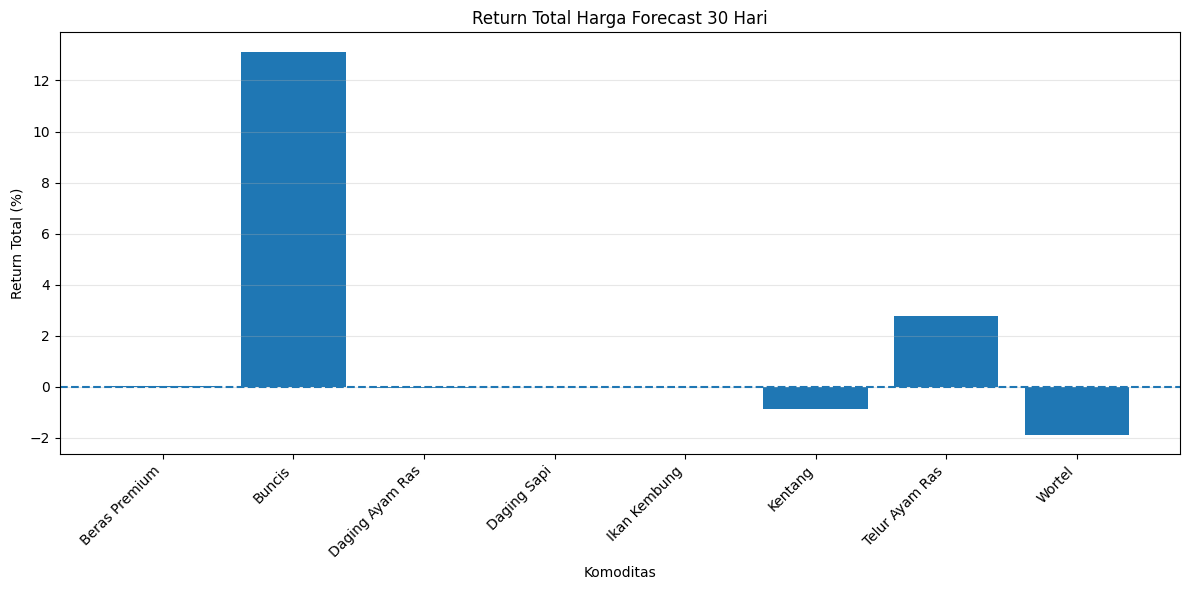

In [ ]:
# ============================================================
# 35. GRAFIK RETURN TOTAL
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(hasil_fpr["Komoditas"], hasil_fpr["Return Total (%)"])
plt.axhline(0, linestyle="--")
plt.title("Return Total Harga Forecast 30 Hari")
plt.xlabel("Komoditas")
plt.ylabel("Return Total (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


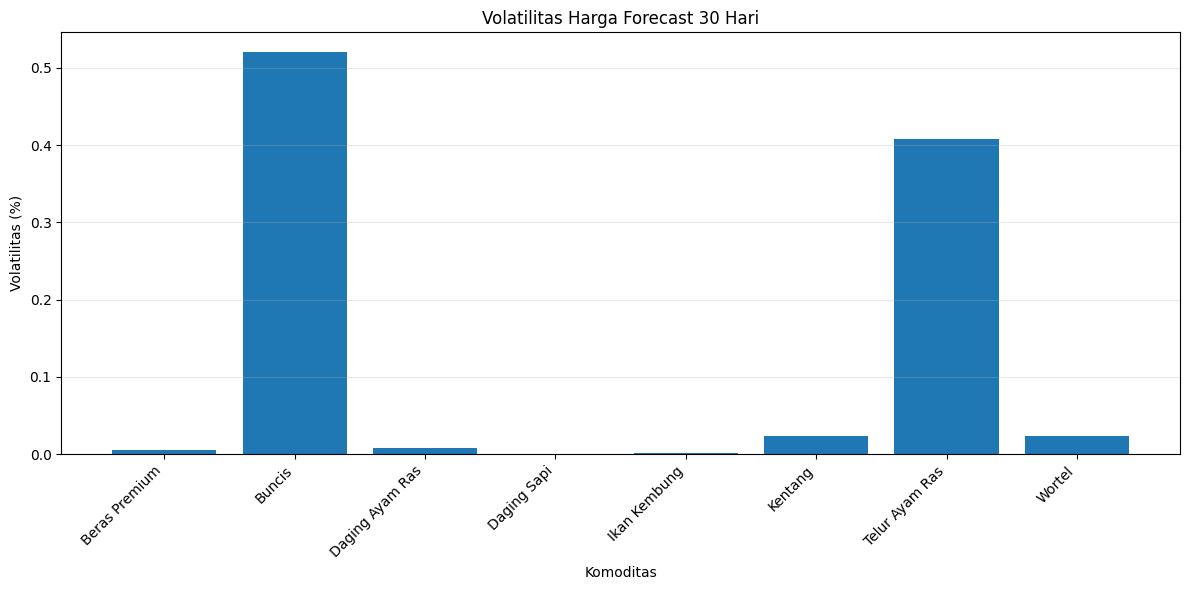

In [ ]:
# ============================================================
# 36. GRAFIK VOLATILITAS
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(hasil_fpr["Komoditas"], hasil_fpr["Volatilitas (%)"])
plt.title("Volatilitas Harga Forecast 30 Hari")
plt.xlabel("Komoditas")
plt.ylabel("Volatilitas (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


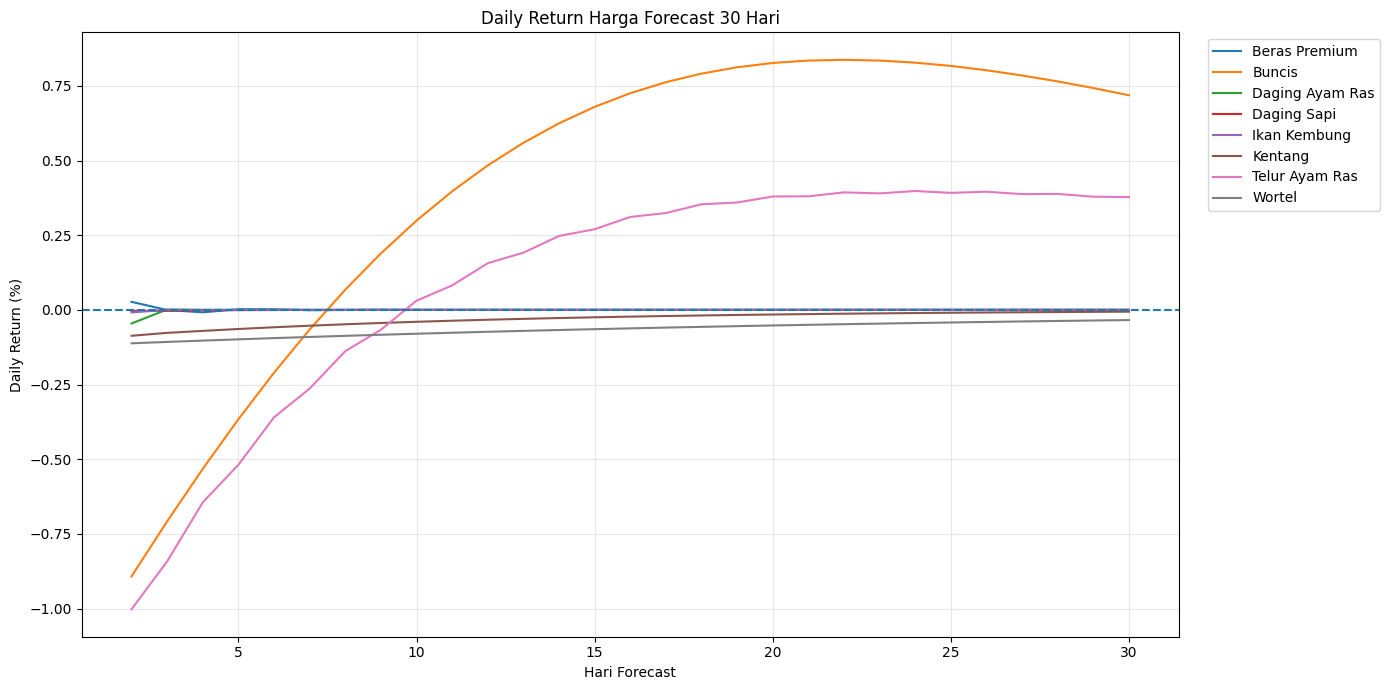

In [ ]:
# ============================================================
# 37. GRAFIK DAILY RETURN
# ============================================================

plt.figure(figsize=(14, 7))

for kom in komoditas_list:
    plt.plot(
        range(1, len(daily_return[kom]) + 1),
        daily_return[kom].values,
        label=kom
    )

plt.axhline(0, linestyle="--")
plt.title("Daily Return Harga Forecast 30 Hari")
plt.xlabel("Hari Forecast")
plt.ylabel("Daily Return (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 38. Validasi Final FPR

Validasi memastikan semua komoditas memiliki harga forecast, return, volatilitas, dan pola FPR.

Jika seluruh baris menunjukkan **VALID**, maka tahap FPR selesai.


In [ ]:
# ============================================================
# 38. VALIDASI FINAL FPR
# ============================================================

validasi = hasil_fpr.copy()

validasi["Validasi Harga"] = np.where(
    validasi["Harga Awal"].notna() &
    validasi["Harga Akhir"].notna(),
    "OK", "Perlu cek"
)

validasi["Validasi Return"] = np.where(
    validasi["Return Total (%)"].notna(),
    "OK", "Perlu cek"
)

validasi["Validasi Volatilitas"] = np.where(
    validasi["Volatilitas (%)"].notna(),
    "OK", "Perlu cek"
)

validasi["Validasi Pola"] = np.where(
    validasi["Pola FPR"].notna() &
    (validasi["Pola FPR"] != ""),
    "OK", "Perlu cek"
)

kolom_validasi = [
    "Validasi Harga",
    "Validasi Return",
    "Validasi Volatilitas",
    "Validasi Pola"
]

validasi["Status Validasi"] = np.where(
    validasi[kolom_validasi].eq("OK").all(axis=1),
    "VALID",
    "PERLU DICEK"
)

display(validasi)

print("=" * 60)
print("RINGKASAN VALIDASI")
print("=" * 60)
print("Jumlah komoditas :", len(validasi))
print("VALID            :", (validasi["Status Validasi"] == "VALID").sum())
print("PERLU DICEK      :", (validasi["Status Validasi"] == "PERLU DICEK").sum())

if (validasi["Status Validasi"] == "PERLU DICEK").any():
    display(validasi[validasi["Status Validasi"] == "PERLU DICEK"])
else:
    print("Semua komoditas VALID.")


,Komoditas,Harga Awal,Harga Akhir,Return Total (%),Volatilitas (%),Tren,Tingkat Volatilitas,Pola FPR,Validasi Harga,Validasi Return,Validasi Volatilitas,Validasi Pola,Status Validasi
0,Beras Premium,14965.252791,14968.422015,0.021177,0.005301,Stabil,Rendah,Sideways,OK,OK,OK,OK,VALID
1,Buncis,9567.204854,10823.799495,13.134397,0.520082,Naik,Tinggi,Volatile Uptrend,OK,OK,OK,OK,VALID
2,Daging Ayam Ras,31734.457549,31720.412051,-0.044259,0.008470,Stabil,Rendah,Sideways,OK,OK,OK,OK,VALID
3,Daging Sapi,125340.373518,125328.280740,-0.009648,0.000867,Stabil,Rendah,Sideways,OK,OK,OK,OK,VALID
4,Ikan Kembung,35513.635065,35510.599827,-0.008547,0.001587,Stabil,Rendah,Sideways,OK,OK,OK,OK,VALID
5,Kentang,15160.362648,15027.237549,-0.878113,0.023240,Turun,Tinggi,Volatile Downtrend,OK,OK,OK,OK,VALID
6,Telur Ayam Ras,22988.609205,23624.102788,2.764385,0.408285,Naik,Tinggi,Volatile Uptrend,OK,OK,OK,OK,VALID
7,Wortel,14607.939127,14331.753655,-1.890653,0.023489,Turun,Tinggi,Volatile Downtrend,OK,OK,OK,OK,VALID


RINGKASAN VALIDASI
Jumlah komoditas : 8
VALID            : 8
PERLU DICEK      : 0
Semua komoditas VALID.


# HASIL AKHIR TAHAP FPR

Tahap FPR dinyatakan selesai jika:
- seluruh komoditas termasuk **Beras Premium**,
- forecast 30 hari tersedia,
- MAE, RMSE, MAPE tersedia,
- residual dan Ljung-Box tersedia,
- daily return tersedia,
- return total dan volatilitas tersedia,
- tren dan pola FPR tersedia,
- validasi menunjukkan seluruh komoditas **VALID**.

Setelah ini dapat dilanjutkan ke **implementasi Grey Wolf Optimizer (GWO)**.


# 40. GREY WOLF OPTIMIZER (GWO)

Pada tahap ini GWO digunakan untuk memperoleh **skor prioritas komoditas** berdasarkan tiga kriteria dari hasil FPR: **harga forecast akhir, return total, dan volatilitas**. Harga dan volatilitas diperlakukan sebagai kriteria biaya (lebih kecil lebih baik), sedangkan return diperlakukan sebagai kriteria manfaat (lebih besar lebih baik).

**Catatan metodologis:** GWO tidak mengubah harga forecast menjadi "Harga GWO". Harga forecast tetap berasal dari ARIMA. Output GWO yang benar adalah skor/ranking prioritas berdasarkan kriteria tersebut.


In [ ]:
# ============================================================
# 40. PERSIAPAN DATA GWO
# ============================================================

data_gwo = hasil_fpr[[
    "Komoditas",
    "Harga Akhir",
    "Return Total (%)",
    "Volatilitas (%)"
]].copy()

data_gwo["Komoditas"] = data_gwo["Komoditas"].astype(str).str.strip()
data_gwo = data_gwo.dropna().reset_index(drop=True)

# Urutan kanonis mengikuti daftar komoditas pada tahap forecasting.
urutan_komoditas = {kom: i for i, kom in enumerate(komoditas_list)}

data_gwo["Urutan"] = data_gwo["Komoditas"].map(urutan_komoditas)
data_gwo = (
    data_gwo
    .dropna(subset=["Urutan"])
    .sort_values("Urutan")
    .drop(columns="Urutan")
    .reset_index(drop=True)
)

if len(data_gwo) != len(komoditas_list):
    raise ValueError(
        f"Jumlah komoditas GWO ({len(data_gwo)}) tidak sama "
        f"dengan jumlah komoditas forecast ({len(komoditas_list)})."
    )


print("Jumlah komoditas GWO :", len(data_gwo))
display(data_gwo)


Jumlah komoditas GWO : 8


,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%)
0,Beras Premium,14968.422015,0.021177,0.005301
1,Buncis,10823.799495,13.134397,0.520082
2,Daging Ayam Ras,31720.412051,-0.044259,0.008470
3,Daging Sapi,125328.280740,-0.009648,0.000867
4,Ikan Kembung,35510.599827,-0.008547,0.001587
5,Kentang,15027.237549,-0.878113,0.023240
6,Telur Ayam Ras,23624.102788,2.764385,0.408285
7,Wortel,14331.753655,-1.890653,0.023489


In [ ]:
# ============================================================
# 41. NORMALISASI KRITERIA GWO
# ============================================================

# Min-Max 0-1
def min_max(data):
    x = np.asarray(data, dtype=float)
    xmin, xmax = np.min(x), np.max(x)
    if np.isclose(xmax, xmin):
        return np.full(len(x), 0.5)
    return (x - xmin) / (xmax - xmin)

# Harga dan volatilitas = biaya (lebih kecil lebih baik)
harga_norm = min_max(data_gwo["Harga Akhir"])
vol_norm = min_max(data_gwo["Volatilitas (%)"])

# Return = manfaat (lebih besar lebih baik), sehingga dibalik menjadi cost
return_benefit_norm = min_max(data_gwo["Return Total (%)"])
return_cost_norm = 1 - return_benefit_norm

data_gwo_norm = data_gwo.copy()
data_gwo_norm["Harga_Norm"] = harga_norm
data_gwo_norm["Return_Norm"] = return_benefit_norm
data_gwo_norm["Return_Cost_Norm"] = return_cost_norm
data_gwo_norm["Volatilitas_Norm"] = vol_norm

print("Normalisasi kriteria GWO:")
display(data_gwo_norm.round(6))


Normalisasi kriteria GWO:


,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%),Harga_Norm,Return_Norm,Return_Cost_Norm,Volatilitas_Norm
0,Beras Premium,14968.422015,0.021177,0.005301,0.036196,0.127243,0.872757,0.008540
1,Buncis,10823.799495,13.134397,0.520082,0.000000,1.000000,0.000000,1.000000
2,Daging Ayam Ras,31720.412051,-0.044259,0.008470,0.182496,0.122888,0.877112,0.014645
3,Daging Sapi,125328.280740,-0.009648,0.000867,1.000000,0.125191,0.874809,0.000000
4,Ikan Kembung,35510.599827,-0.008547,0.001587,0.215597,0.125265,0.874735,0.001388
5,Kentang,15027.237549,-0.878113,0.023240,0.036710,0.067390,0.932610,0.043090
6,Telur Ayam Ras,23624.102788,2.764385,0.408285,0.111789,0.309818,0.690182,0.784682
7,Wortel,14331.753655,-1.890653,0.023489,0.030636,0.000000,1.000000,0.043570


In [ ]:
# ============================================================
# 42. PARAMETER DAN FUNGSI FITNESS GWO
# ============================================================

BOBOT_HARGA = 0.40
BOBOT_RETURN = 0.30
BOBOT_VOLATILITAS = 0.30

if not np.isclose(BOBOT_HARGA + BOBOT_RETURN + BOBOT_VOLATILITAS, 1.0):
    raise ValueError("Total bobot harus sama dengan 1.")

# Fitness komoditas: semakin kecil semakin baik.
# Return menggunakan return_cost agar return tinggi menjadi nilai biaya rendah.

def fitness_komoditas(harga_n, return_cost_n, vol_n):
    return (
        BOBOT_HARGA * harga_n
        + BOBOT_RETURN * return_cost_n
        + BOBOT_VOLATILITAS * vol_n
    )

data_gwo_norm["Fitness Awal"] = fitness_komoditas(
    data_gwo_norm["Harga_Norm"].values,
    data_gwo_norm["Return_Cost_Norm"].values,
    data_gwo_norm["Volatilitas_Norm"].values
)

print("Bobot Harga       :", BOBOT_HARGA)
print("Bobot Return      :", BOBOT_RETURN)
print("Bobot Volatilitas :", BOBOT_VOLATILITAS)
print("Total bobot       :", BOBOT_HARGA + BOBOT_RETURN + BOBOT_VOLATILITAS)

display(data_gwo_norm[["Komoditas","Harga_Akhir" if False else "Harga Akhir","Return Total (%)","Volatilitas (%)","Fitness Awal"]].sort_values("Fitness Awal").reset_index(drop=True).round(6))


Bobot Harga       : 0.4
Bobot Return      : 0.3
Bobot Volatilitas : 0.3
Total bobot       : 1.0


,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%),Fitness Awal
0,Beras Premium,14968.422015,0.021177,0.005301,0.278868
1,Buncis,10823.799495,13.134397,0.520082,0.300000
2,Kentang,15027.237549,-0.878113,0.023240,0.307394
3,Wortel,14331.753655,-1.890653,0.023489,0.325325
4,Daging Ayam Ras,31720.412051,-0.044259,0.008470,0.340525
5,Ikan Kembung,35510.599827,-0.008547,0.001587,0.349076
6,Telur Ayam Ras,23624.102788,2.764385,0.408285,0.487175
7,Daging Sapi,125328.280740,-0.009648,0.000867,0.662443


In [ ]:
# ============================================================
# 43. GWO - OPTIMASI BOBOT KRITERIA
# ============================================================

JUMLAH_SERIGALA = 20
JUMLAH_ITERASI = 50
DIMENSI = 3
BATAS_BAWAH = np.array([0.0, 0.0, 0.0])
BATAS_ATAS = np.array([1.0, 1.0, 1.0])

# Matriks kriteria biaya: harga, return_cost, volatilitas
X = data_gwo_norm[["Harga_Norm", "Return_Cost_Norm", "Volatilitas_Norm"]].values

def normalisasi_bobot(w):
    w = np.clip(np.asarray(w, dtype=float), BATAS_BAWAH, BATAS_ATAS)
    total = w.sum()
    if total <= 0:
        return np.ones(DIMENSI) / DIMENSI
    return w / total

# Fitness bobot: rata-rata skor komposit + penalti ketidakseimbangan.
# Penalti menjaga bobot tidak runtuh ke satu kriteria saja.
def fitness_bobot(w):
    w = normalisasi_bobot(w)
    skor = X @ w
    rata2 = float(np.mean(skor))
    penalti_keseimbangan = 0.05 * float(np.sum((w - 1/DIMENSI)**2))
    return rata2 + penalti_keseimbangan

rng = np.random.default_rng(42)
populasi = rng.uniform(BATAS_BAWAH, BATAS_ATAS, size=(JUMLAH_SERIGALA, DIMENSI))

# Evaluasi awal
nilai_fitness = np.array([fitness_bobot(w) for w in populasi])

# Simpan convergence
riwayat_fitness = []

alpha_posisi = beta_posisi = delta_posisi = None
alpha_fitness = beta_fitness = delta_fitness = np.inf

for iterasi in range(JUMLAH_ITERASI):
    # Evaluasi populasi dan tentukan tiga serigala terbaik
    nilai_fitness = np.array([fitness_bobot(w) for w in populasi])
    urutan = np.argsort(nilai_fitness)

    alpha_posisi = populasi[urutan[0]].copy()
    beta_posisi = populasi[urutan[1]].copy()
    delta_posisi = populasi[urutan[2]].copy()

    alpha_fitness = float(nilai_fitness[urutan[0]])
    beta_fitness = float(nilai_fitness[urutan[1]])
    delta_fitness = float(nilai_fitness[urutan[2]])

    riwayat_fitness.append(alpha_fitness)

    # Parameter GWO menurun linear 2 -> 0
    a = 2 - 2 * (iterasi / (JUMLAH_ITERASI - 1))

    populasi_baru = np.zeros_like(populasi)

    for i in range(JUMLAH_SERIGALA):
        X1 = np.zeros(DIMENSI)
        X2 = np.zeros(DIMENSI)
        X3 = np.zeros(DIMENSI)

        for leader, Xk in [(alpha_posisi, X1), (beta_posisi, X2), (delta_posisi, X3)]:
            r1 = rng.random(DIMENSI)
            r2 = rng.random(DIMENSI)
            A = 2 * a * r1 - a
            C = 2 * r2
            D = np.abs(C * leader - populasi[i])
            Xk[:] = leader - A * D

        populasi_baru[i] = (X1 + X2 + X3) / 3

    populasi = np.clip(populasi_baru, BATAS_BAWAH, BATAS_ATAS)

# Evaluasi akhir
nilai_fitness_akhir = np.array([fitness_bobot(w) for w in populasi])
idx = int(np.argmin(nilai_fitness_akhir))
bobot_optimal = normalisasi_bobot(populasi[idx])
fitness_akhir = float(fitness_bobot(bobot_optimal))

print("============================================================")
print("HASIL GWO")
print("============================================================")
print("Alpha Fitness :", round(alpha_fitness, 8))
print("Beta Fitness  :", round(beta_fitness, 8))
print("Delta Fitness :", round(delta_fitness, 8))
print("Bobot optimal :", np.round(bobot_optimal, 6))
print("Fitness akhir :", round(fitness_akhir, 8))


HASIL GWO
Alpha Fitness : 0.22454971
Beta Fitness  : 0.22454974
Delta Fitness : 0.22454974
Bobot optimal : [0.676063 0.       0.323937]
Fitness akhir : 0.22454973


In [ ]:
# ============================================================
# 44. SKOR DAN RANKING KOMODITAS HASIL GWO
# ============================================================

# Gunakan bobot optimal untuk menghitung skor setiap komoditas.
# Skor lebih kecil = lebih prioritas menurut fungsi tujuan.

data_hasil_gwo = data_gwo_norm.copy()
data_hasil_gwo["Skor GWO"] = (
    bobot_optimal[0] * data_hasil_gwo["Harga_Norm"]
    + bobot_optimal[1] * data_hasil_gwo["Return_Cost_Norm"]
    + bobot_optimal[2] * data_hasil_gwo["Volatilitas_Norm"]
)

data_hasil_gwo = data_hasil_gwo.sort_values("Skor GWO", ascending=True).reset_index(drop=True)
data_hasil_gwo["Peringkat GWO"] = np.arange(1, len(data_hasil_gwo) + 1)

hasil_gwo = data_hasil_gwo[[
    "Peringkat GWO",
    "Komoditas",
    "Harga Akhir",
    "Return Total (%)",
    "Volatilitas (%)",
    "Skor GWO"
]].copy()

print("============================================================")
print("RANKING KOMODITAS HASIL GWO")
print("============================================================")
display(hasil_gwo.round(6))
print("Jumlah komoditas :", len(hasil_gwo))


RANKING KOMODITAS HASIL GWO


,Peringkat GWO,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%),Skor GWO
0,1,Beras Premium,14968.422015,0.021177,0.005301,0.027237
1,2,Wortel,14331.753655,-1.890653,0.023489,0.034826
2,3,Kentang,15027.237549,-0.878113,0.023240,0.038777
3,4,Daging Ayam Ras,31720.412051,-0.044259,0.008470,0.128123
4,5,Ikan Kembung,35510.599827,-0.008547,0.001587,0.146206
5,6,Buncis,10823.799495,13.134397,0.520082,0.323937
6,7,Telur Ayam Ras,23624.102788,2.764385,0.408285,0.329764
7,8,Daging Sapi,125328.280740,-0.009648,0.000867,0.676063


Jumlah komoditas : 8


Bobot optimal GWO:


,Kriteria,Bobot Optimal
0,Harga,0.676063
1,Return,0.000000
2,Volatilitas,0.323937


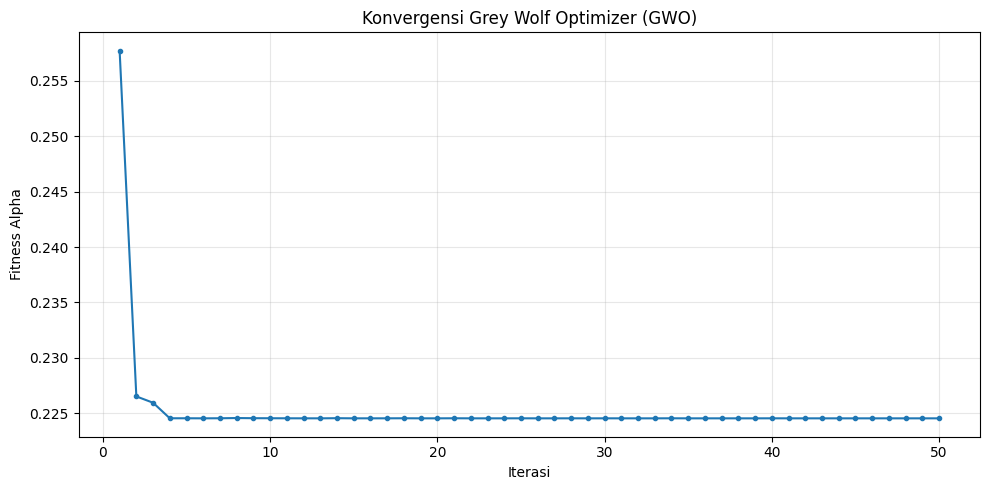

In [ ]:
# ============================================================
# 45. BOBOT DAN KONVERGENSI GWO
# ============================================================

hasil_bobot_gwo = pd.DataFrame({
    "Kriteria": ["Harga", "Return", "Volatilitas"],
    "Bobot Optimal": bobot_optimal
})

print("Bobot optimal GWO:")
display(hasil_bobot_gwo.round(6))

plt.figure(figsize=(10, 5))
plt.plot(range(1, JUMLAH_ITERASI + 1), riwayat_fitness, marker="o", markersize=3)
plt.title("Konvergensi Grey Wolf Optimizer (GWO)")
plt.xlabel("Iterasi")
plt.ylabel("Fitness Alpha")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 46. VALIDASI HASIL GWO
# ============================================================

validasi_gwo = hasil_gwo.copy()
validasi_gwo["Validasi Komoditas"] = np.where(validasi_gwo["Komoditas"].notna(), "OK", "Perlu cek")
validasi_gwo["Validasi Skor"] = np.where(np.isfinite(validasi_gwo["Skor GWO"]), "OK", "Perlu cek")
validasi_gwo["Validasi Peringkat"] = np.where(validasi_gwo["Peringkat GWO"].notna(), "OK", "Perlu cek")
validasi_gwo["Status Validasi"] = np.where(
    validasi_gwo[["Validasi Komoditas","Validasi Skor","Validasi Peringkat"]].eq("OK").all(axis=1),
    "VALID", "PERLU DICEK"
)

display(validasi_gwo)
print("Jumlah komoditas :", len(validasi_gwo))
print("VALID            :", (validasi_gwo["Status Validasi"] == "VALID").sum())
print("PERLU DICEK      :", (validasi_gwo["Status Validasi"] == "PERLU DICEK").sum())


,Peringkat GWO,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%),Skor GWO,Validasi Komoditas,Validasi Skor,Validasi Peringkat,Status Validasi
0,1,Beras Premium,14968.422015,0.021177,0.005301,0.027237,OK,OK,OK,VALID
1,2,Wortel,14331.753655,-1.890653,0.023489,0.034826,OK,OK,OK,VALID
2,3,Kentang,15027.237549,-0.878113,0.023240,0.038777,OK,OK,OK,VALID
3,4,Daging Ayam Ras,31720.412051,-0.044259,0.008470,0.128123,OK,OK,OK,VALID
4,5,Ikan Kembung,35510.599827,-0.008547,0.001587,0.146206,OK,OK,OK,VALID
5,6,Buncis,10823.799495,13.134397,0.520082,0.323937,OK,OK,OK,VALID
6,7,Telur Ayam Ras,23624.102788,2.764385,0.408285,0.329764,OK,OK,OK,VALID
7,8,Daging Sapi,125328.280740,-0.009648,0.000867,0.676063,OK,OK,OK,VALID


Jumlah komoditas : 8
VALID            : 8
PERLU DICEK      : 0


# HASIL AKHIR GWO

Tahap GWO dinyatakan selesai apabila:
- seluruh **8 komoditas** tersedia;
- tidak ada nilai fitness Alpha/Beta/Delta yang kosong atau tidak terdefinisi;
- bobot optimal berjumlah 1;
- setiap komoditas memiliki Skor GWO dan Peringkat GWO;
- validasi GWO menunjukkan seluruh komoditas **VALID**;
- hasil GWO dapat digabungkan dengan komposisi gizi;
- hasil dapat diekspor ke Excel.

**Catatan:** kolom `Harga Akhir` tetap merupakan hasil forecasting ARIMA. GWO menghasilkan `Skor GWO` dan `Peringkat GWO`, bukan mengganti harga forecast menjadi harga baru.


In [ ]:
# ============================================================
# 48. KOMPOSISI GIZI UNTUK OPTIMASI MENU
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("DATA KOMPOSISI GIZI DARI SHEET 02_TKPI")
print("=" * 60)

if df_tkpi_raw is None:
    raise ValueError(
        "Sheet 02_TKPI tidak ditemukan. "
        "Pastikan workbook memiliki sheet 02_TKPI."
    )

tkpi = df_tkpi_raw.copy()
tkpi.columns = [str(c).strip() for c in tkpi.columns]

print("Kolom TKPI:", tkpi.columns.tolist())

# ------------------------------------------------------------
# Deteksi kolom komoditas
# ------------------------------------------------------------
kol_kom_tkpi = next(
    (c for c in tkpi.columns
     if str(c).strip().lower() in ["komoditas", "komoditi", "bahan pangan"]),
    None
)

if kol_kom_tkpi is None:
    raise ValueError("Kolom Komoditas tidak ditemukan pada sheet 02_TKPI.")

# ------------------------------------------------------------
# Deteksi kolom zat gizi
# ------------------------------------------------------------
def cari_kolom_gizi(nama_target, kandidat):
    for c in kandidat:
        if c in tkpi.columns:
            return c

    target = nama_target.lower()
    for c in tkpi.columns:
        cl = str(c).strip().lower()
        if target in cl:
            return c

    return None

kol_energi = cari_kolom_gizi("energi", [
    "Energi (kkal)", "Energi (kkal/100g)", "Energi"
])
kol_protein = cari_kolom_gizi("protein", [
    "Protein (g)", "Protein (g/100g)", "Protein"
])
kol_lemak = cari_kolom_gizi("lemak", [
    "Lemak (g)", "Lemak (g/100g)", "Lemak"
])
kol_karbo = cari_kolom_gizi("karbohidrat", [
    "Karbohidrat (g)", "Karbohidrat (g/100g)", "Karbohidrat"
])

kolom_ditemukan = {
    "Energi": kol_energi,
    "Protein": kol_protein,
    "Lemak": kol_lemak,
    "Karbohidrat": kol_karbo
}

print("Pemetaan kolom gizi:", kolom_ditemukan)

if any(v is None for v in kolom_ditemukan.values()):
    raise ValueError(
        "Ada kolom gizi yang tidak ditemukan pada sheet 02_TKPI. "
        f"Pemetaan saat ini: {kolom_ditemukan}"
    )

# ------------------------------------------------------------
# Mapping nama komoditas TKPI ke nama kanonis forecast
# ------------------------------------------------------------
tkpi["Komoditas"] = tkpi[kol_kom_tkpi].astype(str).str.strip()

def cocokkan_nama_tkpi(nama):
    nama = str(nama).strip().lower()

    for kanonis, aliases in alias_komoditas.items():
        for alias in aliases:
            if nama == alias.lower():
                return kanonis

    return None

tkpi["Komoditas_Kanonis"] = tkpi["Komoditas"].apply(cocokkan_nama_tkpi)
tkpi = tkpi.dropna(subset=["Komoditas_Kanonis"]).copy()

# Jika ada duplikasi, ambil baris pertama untuk setiap komoditas.
tkpi = tkpi.drop_duplicates("Komoditas_Kanonis", keep="first")

data_gizi = tkpi[[
    "Komoditas_Kanonis",
    kol_energi,
    kol_protein,
    kol_lemak,
    kol_karbo
]].copy()

data_gizi = data_gizi.rename(columns={
    "Komoditas_Kanonis": "Komoditas",
    kol_energi: "Energi (kkal/100g)",
    kol_protein: "Protein (g/100g)",
    kol_lemak: "Lemak (g/100g)",
    kol_karbo: "Karbohidrat (g/100g)"
})

for c in [
    "Energi (kkal/100g)",
    "Protein (g/100g)",
    "Lemak (g/100g)",
    "Karbohidrat (g/100g)"
]:
    data_gizi[c] = pd.to_numeric(data_gizi[c], errors="coerce")

# Pastikan semua komoditas forecast memiliki data gizi.
data_gizi = (
    pd.DataFrame({"Komoditas": komoditas_list})
    .merge(data_gizi, on="Komoditas", how="left")
)

kolom_gizi = [
    "Energi (kkal/100g)",
    "Protein (g/100g)",
    "Lemak (g/100g)",
    "Karbohidrat (g/100g)"
]

if data_gizi[kolom_gizi].isna().any().any():
    print("Data gizi yang belum lengkap:")
    display(data_gizi[data_gizi[kolom_gizi].isna().any(axis=1)])
    raise ValueError(
        "Ada komoditas yang belum memiliki data gizi lengkap pada 02_TKPI."
    )

print("Jumlah komoditas gizi :", len(data_gizi))
print("Data gizi lengkap     :", data_gizi[kolom_gizi].notna().all().all())
display(data_gizi)


DATA KOMPOSISI GIZI DARI SHEET 02_TKPI
Kolom TKPI: ['Komoditas', 'Energi (kkal)', 'Protein (g)', 'Lemak (g)', 'Karbohidrat (g)', 'Fe (mg)', 'Zn (mg)']
Pemetaan kolom gizi: {'Energi': 'Energi (kkal)', 'Protein': 'Protein (g)', 'Lemak': 'Lemak (g)', 'Karbohidrat': 'Karbohidrat (g)'}
Jumlah komoditas gizi : 8
Data gizi lengkap     : True


,Komoditas,Energi (kkal/100g),Protein (g/100g),Lemak (g/100g),Karbohidrat (g/100g)
0,Beras Premium,360,6.80,0.70,78.90
1,Buncis,34,2.40,0.30,7.20
2,Daging Ayam Ras,302,18.20,25.00,0.00
3,Daging Sapi,201,18.80,14.00,0.00
4,Ikan Kembung,125,21.30,3.40,2.20
5,Kentang,142,0.90,0.40,33.70
6,Telur Ayam Ras,154,12.40,10.80,0.70
7,Wortel,41,0.93,0.24,9.58


In [ ]:
# ============================================================
# 49. GABUNGKAN HASIL GWO DENGAN KOMPOSISI GIZI
# ============================================================

gwo_gizi = hasil_gwo.merge(
    data_gizi,
    on="Komoditas",
    how="left",
    validate="one_to_one"
)

print("=" * 70)
print("HASIL GWO + KOMPOSISI GIZI")
print("=" * 70)

display(gwo_gizi)

print("\nJumlah komoditas :", len(gwo_gizi))
print(
    "Data gizi lengkap :",
    gwo_gizi[kolom_gizi].notna().all().all()
)

if len(gwo_gizi) != len(komoditas_list):
    raise ValueError("Jumlah baris GWO + gizi tidak sesuai dengan jumlah komoditas.")

if gwo_gizi[kolom_gizi].isna().any().any():
    raise ValueError("Masih terdapat data gizi kosong setelah penggabungan.")


HASIL GWO + KOMPOSISI GIZI


,Peringkat GWO,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%),Skor GWO,Energi (kkal/100g),Protein (g/100g),Lemak (g/100g),Karbohidrat (g/100g)
0,1,Beras Premium,14968.422015,0.021177,0.005301,0.027237,360,6.80,0.70,78.90
1,2,Wortel,14331.753655,-1.890653,0.023489,0.034826,41,0.93,0.24,9.58
2,3,Kentang,15027.237549,-0.878113,0.023240,0.038777,142,0.90,0.40,33.70
3,4,Daging Ayam Ras,31720.412051,-0.044259,0.008470,0.128123,302,18.20,25.00,0.00
4,5,Ikan Kembung,35510.599827,-0.008547,0.001587,0.146206,125,21.30,3.40,2.20
5,6,Buncis,10823.799495,13.134397,0.520082,0.323937,34,2.40,0.30,7.20
6,7,Telur Ayam Ras,23624.102788,2.764385,0.408285,0.329764,154,12.40,10.80,0.70
7,8,Daging Sapi,125328.280740,-0.009648,0.000867,0.676063,201,18.80,14.00,0.00



Jumlah komoditas : 8
Data gizi lengkap : True


In [ ]:
# ============================================================
# HASIL AKHIR GWO + KOMPOSISI GIZI
# ============================================================

hasil_akhir_gwo = gwo_gizi.copy()

print("Kolom hasil_akhir_gwo:")
print(hasil_akhir_gwo.columns.tolist())

print("\n============================================================")
print("HASIL AKHIR GWO + KOMPOSISI GIZI")
print("============================================================")

display(hasil_akhir_gwo)

print("\nJumlah komoditas :", len(hasil_akhir_gwo))
print(
    "Data gizi lengkap :",
    hasil_akhir_gwo[kolom_gizi].notna().all().all()
)



Kolom hasil_akhir_gwo:
['Peringkat GWO', 'Komoditas', 'Harga Akhir', 'Return Total (%)', 'Volatilitas (%)', 'Skor GWO', 'Energi (kkal/100g)', 'Protein (g/100g)', 'Lemak (g/100g)', 'Karbohidrat (g/100g)']

HASIL AKHIR GWO + KOMPOSISI GIZI


,Peringkat GWO,Komoditas,Harga Akhir,Return Total (%),Volatilitas (%),Skor GWO,Energi (kkal/100g),Protein (g/100g),Lemak (g/100g),Karbohidrat (g/100g)
0,1,Beras Premium,14968.422015,0.021177,0.005301,0.027237,360,6.80,0.70,78.90
1,2,Wortel,14331.753655,-1.890653,0.023489,0.034826,41,0.93,0.24,9.58
2,3,Kentang,15027.237549,-0.878113,0.023240,0.038777,142,0.90,0.40,33.70
3,4,Daging Ayam Ras,31720.412051,-0.044259,0.008470,0.128123,302,18.20,25.00,0.00
4,5,Ikan Kembung,35510.599827,-0.008547,0.001587,0.146206,125,21.30,3.40,2.20
5,6,Buncis,10823.799495,13.134397,0.520082,0.323937,34,2.40,0.30,7.20
6,7,Telur Ayam Ras,23624.102788,2.764385,0.408285,0.329764,154,12.40,10.80,0.70
7,8,Daging Sapi,125328.280740,-0.009648,0.000867,0.676063,201,18.80,14.00,0.00



Jumlah komoditas : 8
Data gizi lengkap : True


In [ ]:
# ============================================================
# CEK DATA KEBUTUHAN GIZI UNTUK OPTIMASI GWO
# ============================================================

print("Variabel yang berkaitan dengan kebutuhan gizi:")

for nama in [
    "target_gizi",
    "kebutuhan_gizi",
    "AKG",
    "akg",
    "data_akg",
    "df_akg",
    "hasil_akg"
]:
    if nama in globals():
        print("TERSedia :", nama)

Variabel yang berkaitan dengan kebutuhan gizi:


In [ ]:
# ============================================================
# 51. VARIABEL KEBUTUHAN GIZI
# ============================================================

# Variabel gizi yang digunakan dalam optimasi
kolom_gizi = [
    "Energi (kkal/100g)",
    "Protein (g/100g)",
    "Lemak (g/100g)",
    "Karbohidrat (g/100g)"
]

print("=" * 60)
print("VARIABEL YANG BERKAITAN DENGAN KEBUTUHAN GIZI")
print("=" * 60)

for kolom in kolom_gizi:
    print("-", kolom)

# Cek apakah seluruh variabel gizi tersedia
kolom_tersedia = [
    kolom for kolom in kolom_gizi
    if kolom in hasil_akhir_gwo.columns
]

kolom_tidak_tersedia = [
    kolom for kolom in kolom_gizi
    if kolom not in hasil_akhir_gwo.columns
]

print("\nJumlah variabel gizi tersedia :", len(kolom_tersedia))

if len(kolom_tidak_tersedia) == 0:
    print("Status: SEMUA VARIABEL GIZI TERSEDIA")
else:
    print("Status: ADA VARIABEL YANG BELUM TERSEDIA")
    print("Tidak tersedia:", kolom_tidak_tersedia)

# Tampilkan data gizi
display(
    hasil_akhir_gwo[
        ["Komoditas"] + kolom_gizi
    ]
)

VARIABEL YANG BERKAITAN DENGAN KEBUTUHAN GIZI
- Energi (kkal/100g)
- Protein (g/100g)
- Lemak (g/100g)
- Karbohidrat (g/100g)

Jumlah variabel gizi tersedia : 4
Status: SEMUA VARIABEL GIZI TERSEDIA


,Komoditas,Energi (kkal/100g),Protein (g/100g),Lemak (g/100g),Karbohidrat (g/100g)
0,Beras Premium,360,6.80,0.70,78.90
1,Wortel,41,0.93,0.24,9.58
2,Kentang,142,0.90,0.40,33.70
3,Daging Ayam Ras,302,18.20,25.00,0.00
4,Ikan Kembung,125,21.30,3.40,2.20
5,Buncis,34,2.40,0.30,7.20
6,Telur Ayam Ras,154,12.40,10.80,0.70
7,Daging Sapi,201,18.80,14.00,0.00


In [ ]:
# ============================================================
# 52. GWO OPTIMASI MENU
# PEMENUHAN TARGET GIZI + MINIMASI BIAYA
# ============================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("GWO OPTIMASI MENU - PEMENUHAN GIZI DAN MINIMASI BIAYA")
print("=" * 75)

# ============================================================
# 1. TARGET KEBUTUHAN GIZI
# ============================================================

TARGET_ENERGI = 1350       # kkal/hari
TARGET_PROTEIN = 20        # gram/hari
TARGET_LEMAK = 45          # gram/hari
TARGET_KARBOHIDRAT = 215   # gram/hari

print("\nTARGET KEBUTUHAN GIZI")
print("Energi       :", TARGET_ENERGI, "kkal/hari")
print("Protein      :", TARGET_PROTEIN, "g/hari")
print("Lemak        :", TARGET_LEMAK, "g/hari")
print("Karbohidrat  :", TARGET_KARBOHIDRAT, "g/hari")


# ============================================================
# 2. DATA KOMODITAS
# ============================================================

komoditas = hasil_akhir_gwo["Komoditas"].values

energi = hasil_akhir_gwo["Energi (kkal/100g)"].astype(float).values
protein = hasil_akhir_gwo["Protein (g/100g)"].astype(float).values
lemak = hasil_akhir_gwo["Lemak (g/100g)"].astype(float).values
karbo = hasil_akhir_gwo["Karbohidrat (g/100g)"].astype(float).values
harga = hasil_akhir_gwo["Harga Akhir"].astype(float).values

DIMENSI = len(komoditas)

if DIMENSI != 8:
    raise ValueError(
        f"Jumlah komoditas harus 8, tetapi ditemukan {DIMENSI}."
    )

print("\nJumlah komoditas :", DIMENSI)
print("Komoditas        :", list(komoditas))


# ============================================================
# 3. PARAMETER GWO
# ============================================================

JUMLAH_SERIGALA = 50
JUMLAH_ITERASI = 300
JUMLAH_RUN = 10

# Batas porsi mengikuti rancangan notebook saat ini.
# Jika tesis mensyaratkan porsi minimum/maksimum yang realistis,
# ubah kedua parameter ini berdasarkan dasar metodologis penelitian.
BATAS_BAWAH = 0.0
BATAS_ATAS = 300.0

print("\nPARAMETER GWO")
print("Jumlah serigala :", JUMLAH_SERIGALA)
print("Jumlah iterasi  :", JUMLAH_ITERASI)
print("Jumlah run      :", JUMLAH_RUN)
print("Batas porsi     :", BATAS_BAWAH, "-", BATAS_ATAS, "gram")


# ============================================================
# 4. FUNGSI MENGHITUNG GIZI
# ============================================================

def hitung_gizi(posisi):
    total_energi = np.sum(posisi * energi / 100)
    total_protein = np.sum(posisi * protein / 100)
    total_lemak = np.sum(posisi * lemak / 100)
    total_karbo = np.sum(posisi * karbo / 100)

    return (
        total_energi,
        total_protein,
        total_lemak,
        total_karbo
    )


# ============================================================
# 5. FUNGSI BIAYA
# ============================================================

def hitung_biaya(posisi):
    return np.sum(posisi / 1000 * harga)


# ============================================================
# 6. FUNGSI KEKURANGAN GIZI
# ============================================================

def hitung_defisit(posisi):

    total_energi, total_protein, total_lemak, total_karbo = \
        hitung_gizi(posisi)

    def deficit(total, target):
        return max(0.0, target - total) / target

    d_energi = deficit(total_energi, TARGET_ENERGI)
    d_protein = deficit(total_protein, TARGET_PROTEIN)
    d_lemak = deficit(total_lemak, TARGET_LEMAK)
    d_karbo = deficit(total_karbo, TARGET_KARBOHIDRAT)

    total_deficit = (
        d_energi + d_protein + d_lemak + d_karbo
    )

    return total_deficit


# ============================================================
# 7. FUNGSI FITNESS
#
# TUJUAN UTAMA:
#   MEMINIMALKAN BIAYA
#
# KENDALA:
#   Semua target gizi minimal harus terpenuhi.
#
# Prinsip:
#   - Solusi yang kekurangan gizi selalu lebih buruk.
#   - Jika dua solusi sama-sama memenuhi target, solusi
#     dengan biaya lebih rendah dipilih.
# ============================================================

def fitness_menu(posisi):

    biaya = hitung_biaya(posisi)
    total_deficit = hitung_defisit(posisi)

    # Penalti sangat besar untuk setiap kekurangan gizi.
    # Biaya dinormalisasi agar skala fitness stabil.
    PENALTI_GIZI = 1_000_000.0
    biaya_norm = biaya / 10_000.0

    fitness = (
        PENALTI_GIZI * total_deficit
        + biaya_norm
    )

    return float(fitness)


# ============================================================
# 8. PEMERIKSAAN KELAYAKAN
# ============================================================

def cek_kelayakan(posisi):

    e, p, l, k = hitung_gizi(posisi)

    return (
        e >= TARGET_ENERGI
        and p >= TARGET_PROTEIN
        and l >= TARGET_LEMAK
        and k >= TARGET_KARBOHIDRAT
    )


# ============================================================
# 9. SATU PROSES GWO
# ============================================================

def jalankan_gwo(seed):

    rng = np.random.default_rng(seed)

    populasi = rng.uniform(
        BATAS_BAWAH,
        BATAS_ATAS,
        size=(JUMLAH_SERIGALA, DIMENSI)
    )

    alpha_posisi = None
    beta_posisi = None
    delta_posisi = None

    alpha_fitness = np.inf
    beta_fitness = np.inf
    delta_fitness = np.inf

    riwayat_fitness = []

    for iterasi in range(JUMLAH_ITERASI):

        nilai_fitness = np.array([
            fitness_menu(posisi)
            for posisi in populasi
        ])

        urutan = np.argsort(nilai_fitness)

        alpha_idx = urutan[0]
        beta_idx = urutan[1]
        delta_idx = urutan[2]

        alpha_posisi = populasi[alpha_idx].copy()
        beta_posisi = populasi[beta_idx].copy()
        delta_posisi = populasi[delta_idx].copy()

        alpha_fitness = float(nilai_fitness[alpha_idx])
        beta_fitness = float(nilai_fitness[beta_idx])
        delta_fitness = float(nilai_fitness[delta_idx])

        riwayat_fitness.append(alpha_fitness)

        a = 2 - (
            2 * iterasi /
            max(1, JUMLAH_ITERASI - 1)
        )

        populasi_baru = np.zeros_like(populasi)

        for i in range(JUMLAH_SERIGALA):

            X1 = np.zeros(DIMENSI)
            X2 = np.zeros(DIMENSI)
            X3 = np.zeros(DIMENSI)

            for leader, Xk in [
                (alpha_posisi, X1),
                (beta_posisi, X2),
                (delta_posisi, X3)
            ]:

                r1 = rng.random(DIMENSI)
                r2 = rng.random(DIMENSI)

                A = 2 * a * r1 - a
                C = 2 * r2

                D = np.abs(
                    C * leader - populasi[i]
                )

                Xk[:] = leader - A * D

            populasi_baru[i] = (
                X1 + X2 + X3
            ) / 3.0

        populasi = np.clip(
            populasi_baru,
            BATAS_BAWAH,
            BATAS_ATAS
        )

    # Evaluasi populasi akhir
    nilai_fitness_final = np.array([
        fitness_menu(posisi)
        for posisi in populasi
    ])

    # --------------------------------------------------------
    # Pilih solusi TERBAIK:
    # 1. Jika ada solusi feasible, pilih biaya terendah.
    # 2. Jika belum ada solusi feasible, pilih defisit terkecil.
    # --------------------------------------------------------

    feasible_idx = [
        i for i, posisi in enumerate(populasi)
        if cek_kelayakan(posisi)
    ]

    if feasible_idx:

        idx_terbaik = min(
            feasible_idx,
            key=lambda i: hitung_biaya(populasi[i])
        )

    else:

        idx_terbaik = min(
            range(len(populasi)),
            key=lambda i: (
                hitung_defisit(populasi[i]),
                hitung_biaya(populasi[i])
            )
        )

    posisi_terbaik = populasi[idx_terbaik].copy()

    return {
        "posisi": posisi_terbaik,
        "fitness": fitness_menu(posisi_terbaik),
        "biaya": hitung_biaya(posisi_terbaik),
        "defisit": hitung_defisit(posisi_terbaik),
        "feasible": cek_kelayakan(posisi_terbaik),
        "riwayat": riwayat_fitness
    }


# ============================================================
# 10. MULTI-RUN GWO
#
# Beberapa run digunakan untuk mengurangi ketergantungan
# terhadap satu inisialisasi acak.
# ============================================================

hasil_run = []

for run in range(JUMLAH_RUN):

    hasil_run.append(
        jalankan_gwo(
            seed=42 + run
        )
    )

# Solusi feasible dengan biaya terendah
solusi_feasible = [
    hasil for hasil in hasil_run
    if hasil["feasible"]
]

if solusi_feasible:

    solusi_terbaik = min(
        solusi_feasible,
        key=lambda x: x["biaya"]
    )

else:

    solusi_terbaik = min(
        hasil_run,
        key=lambda x: (
            x["defisit"],
            x["biaya"]
        )
    )


# ============================================================
# 11. SIMPAN SOLUSI TERBAIK
# ============================================================

posisi_optimal = solusi_terbaik["posisi"].copy()
alpha_fitness = solusi_terbaik["fitness"]

(
    total_energi,
    total_protein,
    total_lemak,
    total_karbo
) = hitung_gizi(posisi_optimal)

biaya_total = hitung_biaya(posisi_optimal)


# ============================================================
# 12. TABEL MENU OPTIMAL
# ============================================================

hasil_menu_gwo = pd.DataFrame({

    "Komoditas": komoditas,

    "Porsi Optimal (gram)": np.round(
        posisi_optimal, 2
    ),

    "Harga/kg": np.round(
        harga, 2
    ),

    "Energi (kkal)": np.round(
        posisi_optimal * energi / 100,
        2
    ),

    "Protein (g)": np.round(
        posisi_optimal * protein / 100,
        2
    ),

    "Lemak (g)": np.round(
        posisi_optimal * lemak / 100,
        2
    ),

    "Karbohidrat (g)": np.round(
        posisi_optimal * karbo / 100,
        2
    ),

    "Biaya (Rp)": np.round(
        posisi_optimal / 1000 * harga,
        2
    )
})


# ============================================================
# 13. KOMODITAS YANG DIGUNAKAN
# ============================================================

menu_digunakan = hasil_menu_gwo[
    hasil_menu_gwo["Porsi Optimal (gram)"] > 0.01
].copy()

menu_digunakan = menu_digunakan.reset_index(drop=True)


# ============================================================
# 14. VALIDASI TARGET GIZI
# ============================================================

ringkasan_gizi = pd.DataFrame({

    "Komponen": [
        "Energi",
        "Protein",
        "Lemak",
        "Karbohidrat",
        "Total Biaya"
    ],

    "Target": [
        TARGET_ENERGI,
        TARGET_PROTEIN,
        TARGET_LEMAK,
        TARGET_KARBOHIDRAT,
        "-"
    ],

    "Hasil GWO": [
        round(total_energi, 2),
        round(total_protein, 2),
        round(total_lemak, 2),
        round(total_karbo, 2),
        round(biaya_total, 2)
    ],

    "Selisih": [
        round(total_energi - TARGET_ENERGI, 2),
        round(total_protein - TARGET_PROTEIN, 2),
        round(total_lemak - TARGET_LEMAK, 2),
        round(total_karbo - TARGET_KARBOHIDRAT, 2),
        "-"
    ],

    "Status": [
        "TERPENUHI"
        if total_energi >= TARGET_ENERGI
        else "TIDAK TERPENUHI",

        "TERPENUHI"
        if total_protein >= TARGET_PROTEIN
        else "TIDAK TERPENUHI",

        "TERPENUHI"
        if total_lemak >= TARGET_LEMAK
        else "TIDAK TERPENUHI",

        "TERPENUHI"
        if total_karbo >= TARGET_KARBOHIDRAT
        else "TIDAK TERPENUHI",

        "-"
    ]
})


# ============================================================
# 15. TABEL HASIL MULTI-RUN
# ============================================================

tabel_run_gwo = pd.DataFrame({

    "Run": np.arange(1, JUMLAH_RUN + 1),

    "Fitness": [
        round(x["fitness"], 8)
        for x in hasil_run
    ],

    "Total Biaya (Rp)": [
        round(x["biaya"], 2)
        for x in hasil_run
    ],

    "Defisit Gizi": [
        round(x["defisit"], 8)
        for x in hasil_run
    ],

    "Feasible": [
        "YA" if x["feasible"] else "TIDAK"
        for x in hasil_run
    ]
})

tabel_run_gwo = tabel_run_gwo.sort_values(
    by=["Feasible", "Total Biaya (Rp)"],
    ascending=[False, True]
).reset_index(drop=True)


# ============================================================
# 16. HASIL AKHIR
# ============================================================

semua_terpenuhi = cek_kelayakan(
    posisi_optimal
)

print("\n")
print("=" * 75)
print("HASIL AKHIR GWO OPTIMASI MENU")
print("=" * 75)

print("\nJumlah run GWO :", JUMLAH_RUN)
print("Fitness terbaik:", round(alpha_fitness, 8))

print("\nTOTAL GIZI")

print(
    "Energi       :",
    round(total_energi, 2),
    "/",
    TARGET_ENERGI,
    "kkal"
)

print(
    "Protein      :",
    round(total_protein, 2),
    "/",
    TARGET_PROTEIN,
    "g"
)

print(
    "Lemak        :",
    round(total_lemak, 2),
    "/",
    TARGET_LEMAK,
    "g"
)

print(
    "Karbohidrat  :",
    round(total_karbo, 2),
    "/",
    TARGET_KARBOHIDRAT,
    "g"
)

print(
    "\nTOTAL BIAYA MENU : Rp",
    round(biaya_total, 2)
)

print(
    "\nSTATUS TARGET GIZI :",
    "SEMUA TARGET TERPENUHI"
    if semua_terpenuhi
    else "MASIH ADA TARGET YANG BELUM TERPENUHI"
)

print("\n")
print("=" * 75)
print("KOMBINASI MENU OPTIMAL")
print("=" * 75)

display(menu_digunakan)

print("\n")
print("=" * 75)
print("VALIDASI KEBUTUHAN GIZI")
print("=" * 75)

display(ringkasan_gizi)

print("\n")
print("=" * 75)
print("PERBANDINGAN HASIL MULTI-RUN GWO")
print("=" * 75)

display(tabel_run_gwo)


In [ ]:
# ============================================================
# 53. EVALUASI HASIL OPTIMASI GWO
# ============================================================

print("=" * 70)
print("EVALUASI HASIL OPTIMASI GWO")
print("=" * 70)

target_gizi = {
    "Energi (kkal)": TARGET_ENERGI,
    "Protein (g)": TARGET_PROTEIN,
    "Lemak (g)": TARGET_LEMAK,
    "Karbohidrat (g)": TARGET_KARBOHIDRAT
}

evaluasi_gizi = []

for komponen, target in target_gizi.items():

    hasil = float(
        hasil_menu_gwo[
            komponen
        ].sum()
    )

    selisih = hasil - target
    pemenuhan = hasil / target * 100
    deviasi = selisih / target * 100

    evaluasi_gizi.append({
        "Komponen Gizi": komponen,
        "Target Minimum": target,
        "Hasil GWO": round(hasil, 2),
        "Selisih": round(selisih, 2),
        "Pemenuhan (%)": round(pemenuhan, 2),
        "Deviasi (%)": round(deviasi, 2),
        "Status": (
            "TERPENUHI"
            if hasil >= target
            else "TIDAK TERPENUHI"
        )
    })

evaluasi_gizi = pd.DataFrame(
    evaluasi_gizi
)

total_porsi = float(
    hasil_menu_gwo[
        "Porsi Optimal (gram)"
    ].sum()
)

total_biaya = float(
    hasil_menu_gwo[
        "Biaya (Rp)"
    ].sum()
)

print("\nTABEL EVALUASI GIZI")
display(evaluasi_gizi)

print("\nTOTAL PORSI :", round(total_porsi, 2), "gram")
print("TOTAL BIAYA :", f"Rp {total_biaya:,.2f}")

print("\nKESIMPULAN KELAYAKAN")

if semua_terpenuhi:
    print(
        "SEMUA TARGET GIZI TERPENUHI. "
        "Solusi dipilih berdasarkan biaya terendah "
        "di antara solusi feasible yang ditemukan GWO."
    )
else:
    print(
        "SOLUSI BELUM FEASIBLE. "
        "Perlu penyesuaian parameter atau batas porsi."
    )


In [ ]:
# ============================================================
# 54. KOMBINASI MENU OPTIMAL HASIL GWO
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# 1. Ambil data gizi dari hasil akhir GWO
# ------------------------------------------------------------

# Pastikan urutan komoditas mengikuti hasil GWO
komoditas_final = hasil_akhir_gwo["Komoditas"].tolist()

energi = hasil_akhir_gwo["Energi (kkal/100g)"].to_numpy(dtype=float)
protein = hasil_akhir_gwo["Protein (g/100g)"].to_numpy(dtype=float)
lemak = hasil_akhir_gwo["Lemak (g/100g)"].to_numpy(dtype=float)
karbohidrat = hasil_akhir_gwo["Karbohidrat (g/100g)"].to_numpy(dtype=float)

harga = hasil_akhir_gwo["Harga Akhir"].to_numpy(dtype=float)

# ------------------------------------------------------------
# 2. Posisi/porsi optimal hasil GWO
# ------------------------------------------------------------

posisi_final = solusi_terbaik["posisi"]
posisi_final = np.asarray(posisi_final, dtype=float)

# Pastikan jumlah data sama
if len(posisi_final) != len(komoditas_final):
    raise ValueError(
        f"Jumlah posisi GWO ({len(posisi_final)}) "
        f"tidak sama dengan jumlah komoditas ({len(komoditas_final)})."
    )

# ------------------------------------------------------------
# 3. Hitung kontribusi gizi dan biaya
# ------------------------------------------------------------

tabel_menu_final = pd.DataFrame({
    "Komoditas": komoditas_final,
    "Porsi Optimal (g)": posisi_final,
    "Harga/kg (Rp)": harga,

    "Energi (kkal)": posisi_final * energi / 100,
    "Protein (g)": posisi_final * protein / 100,
    "Lemak (g)": posisi_final * lemak / 100,
    "Karbohidrat (g)": posisi_final * karbohidrat / 100,

    "Biaya (Rp)": posisi_final * harga / 1000
})

# ------------------------------------------------------------
# 4. Tambahkan TOTAL
# ------------------------------------------------------------

total_row = pd.DataFrame({
    "Komoditas": ["TOTAL"],
    "Porsi Optimal (g)": [tabel_menu_final["Porsi Optimal (g)"].sum()],
    "Harga/kg (Rp)": [np.nan],
    "Energi (kkal)": [tabel_menu_final["Energi (kkal)"].sum()],
    "Protein (g)": [tabel_menu_final["Protein (g)"].sum()],
    "Lemak (g)": [tabel_menu_final["Lemak (g)"].sum()],
    "Karbohidrat (g)": [tabel_menu_final["Karbohidrat (g)"].sum()],
    "Biaya (Rp)": [tabel_menu_final["Biaya (Rp)"].sum()]
})

tabel_menu_final = pd.concat(
    [tabel_menu_final, total_row],
    ignore_index=True
)

# ------------------------------------------------------------
# 5. Tampilkan hasil
# ------------------------------------------------------------

print("=" * 70)
print("KOMBINASI MENU OPTIMAL HASIL GWO")
print("=" * 70)

display(tabel_menu_final)

print("\nTOTAL GIZI:")
print(f"Energi       : {total_row['Energi (kkal)'].iloc[0]:.2f} kkal")
print(f"Protein      : {total_row['Protein (g)'].iloc[0]:.2f} g")
print(f"Lemak        : {total_row['Lemak (g)'].iloc[0]:.2f} g")
print(f"Karbohidrat  : {total_row['Karbohidrat (g)'].iloc[0]:.2f} g")
print(f"Total biaya  : Rp {total_row['Biaya (Rp)'].iloc[0]:,.2f}")

In [ ]:
# ============================================================
# 55. VALIDASI TARGET GIZI
# ============================================================

hasil_energi = tabel_menu_final.loc[
    tabel_menu_final["Komoditas"] == "TOTAL",
    "Energi (kkal)"
].iloc[0]

hasil_protein = tabel_menu_final.loc[
    tabel_menu_final["Komoditas"] == "TOTAL",
    "Protein (g)"
].iloc[0]

hasil_lemak = tabel_menu_final.loc[
    tabel_menu_final["Komoditas"] == "TOTAL",
    "Lemak (g)"
].iloc[0]

hasil_karbohidrat = tabel_menu_final.loc[
    tabel_menu_final["Komoditas"] == "TOTAL",
    "Karbohidrat (g)"
].iloc[0]

hasil_biaya = tabel_menu_final.loc[
    tabel_menu_final["Komoditas"] == "TOTAL",
    "Biaya (Rp)"
].iloc[0]


validasi_final = pd.DataFrame({

    "Komponen Gizi": [
        "Energi (kkal)",
        "Protein (g)",
        "Lemak (g)",
        "Karbohidrat (g)"
    ],

    "Target Minimum": [
        TARGET_ENERGI,
        TARGET_PROTEIN,
        TARGET_LEMAK,
        TARGET_KARBOHIDRAT
    ],

    "Hasil GWO": [
        hasil_energi,
        hasil_protein,
        hasil_lemak,
        hasil_karbohidrat
    ]
})

validasi_final["Selisih"] = (
    validasi_final["Hasil GWO"]
    - validasi_final["Target Minimum"]
)

validasi_final["Pemenuhan (%)"] = (
    validasi_final["Hasil GWO"]
    / validasi_final["Target Minimum"]
    * 100
)

validasi_final["Status"] = np.where(
    validasi_final["Hasil GWO"]
    >= validasi_final["Target Minimum"],
    "TERPENUHI",
    "TIDAK TERPENUHI"
)

validasi_final = validasi_final.round(2)

print("=" * 80)
print("VALIDASI HASIL OPTIMASI GWO")
print("=" * 80)

display(validasi_final)

print("\nTOTAL BIAYA OPTIMAL:")
print(f"Rp {hasil_biaya:,.2f}")

In [ ]:
# ============================================================
# 56. EVALUASI BIAYA DAN PORSI HASIL OPTIMASI GWO
# ============================================================

print("=" * 70)
print("EVALUASI BIAYA DAN PORSI HASIL OPTIMASI GWO")
print("=" * 70)

total_porsi = hasil_menu_gwo["Porsi Optimal (gram)"].sum()
total_biaya = hasil_menu_gwo["Biaya (Rp)"].sum()

evaluasi_biaya = hasil_menu_gwo[
    hasil_menu_gwo["Porsi Optimal (gram)"] > 0.01
].copy()

evaluasi_biaya["Kontribusi Biaya (%)"] = (
    evaluasi_biaya["Biaya (Rp)"]
    / total_biaya * 100
)

evaluasi_biaya["Kontribusi Porsi (%)"] = (
    evaluasi_biaya["Porsi Optimal (gram)"]
    / total_porsi * 100
)

evaluasi_biaya = evaluasi_biaya[
    [
        "Komoditas",
        "Porsi Optimal (gram)",
        "Harga/kg",
        "Biaya (Rp)",
        "Kontribusi Biaya (%)",
        "Kontribusi Porsi (%)"
    ]
].copy()

evaluasi_biaya = evaluasi_biaya.round(2)

evaluasi_biaya = evaluasi_biaya.sort_values(
    "Biaya (Rp)",
    ascending=False
).reset_index(drop=True)

print("\nJUMLAH KOMODITAS YANG DIGUNAKAN:",
      len(evaluasi_biaya))

print("TOTAL PORSI:",
      round(total_porsi, 2), "gram")

print("TOTAL BIAYA:",
      f"Rp {total_biaya:,.2f}")

print("\nTABEL EVALUASI BIAYA")
display(evaluasi_biaya)

print("\nKOMODITAS DENGAN BIAYA TERBESAR")

if len(evaluasi_biaya) > 0:
    terbesar = evaluasi_biaya.iloc[0]

    print(
        f"Komoditas        : {terbesar['Komoditas']}"
    )
    print(
        f"Porsi            : "
        f"{terbesar['Porsi Optimal (gram)']:.2f} gram"
    )
    print(
        f"Biaya            : "
        f"Rp {terbesar['Biaya (Rp)']:,.2f}"
    )
    print(
        f"Kontribusi biaya : "
        f"{terbesar['Kontribusi Biaya (%)']:.2f}%"
    )


In [ ]:
# ============================================================
# 57. VISUALISASI HASIL OPTIMASI GWO
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GRAFIK 1: TARGET VS HASIL GWO
# ------------------------------------------------------------

komponen = evaluasi_gizi["Komponen Gizi"].tolist()
target = evaluasi_gizi["Target Minimum"].astype(float).tolist()
hasil = evaluasi_gizi["Hasil GWO"].astype(float).tolist()

x = np.arange(len(komponen))
lebar = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - lebar / 2,
    target,
    width=lebar,
    label="Target Minimum"
)

plt.bar(
    x + lebar / 2,
    hasil,
    width=lebar,
    label="Hasil GWO"
)

plt.xticks(
    x,
    komponen,
    rotation=20
)

plt.ylabel("Nilai Gizi")
plt.title(
    "Perbandingan Target Minimum dan Hasil Optimasi GWO"
)

plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRAFIK 2: PORSI KOMBINASI MENU OPTIMAL
# ------------------------------------------------------------

data_porsi = menu_digunakan.sort_values(
    "Porsi Optimal (gram)",
    ascending=False
)

plt.figure(figsize=(11, 6))

plt.bar(
    data_porsi["Komoditas"],
    data_porsi["Porsi Optimal (gram)"]
)

plt.xlabel("Komoditas")
plt.ylabel("Porsi Optimal (gram)")
plt.title(
    "Porsi Optimal Kombinasi Menu Hasil GWO"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRAFIK 3: BIAYA KOMBINASI MENU
# ------------------------------------------------------------

data_biaya = evaluasi_biaya.sort_values(
    "Biaya (Rp)",
    ascending=False
)

plt.figure(figsize=(11, 6))

plt.bar(
    data_biaya["Komoditas"],
    data_biaya["Biaya (Rp)"]
)

plt.xlabel("Komoditas")
plt.ylabel("Biaya (Rp)")
plt.title(
    "Biaya Setiap Komoditas dalam Menu Optimal GWO"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRAFIK 4: KONVERGENSI GWO
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    solusi_terbaik["riwayat"]
)

plt.xlabel("Iterasi")
plt.ylabel("Fitness Terbaik")
plt.title(
    "Konvergensi Grey Wolf Optimizer"
)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 58. FINALISASI HASIL OPTIMASI MENU GWO
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("HASIL AKHIR OPTIMASI MENU GWO")
print("=" * 70)

# ------------------------------------------------------------
# 1. Ambil hanya baris komoditas
# ------------------------------------------------------------

kolom_menu = [
    "Komoditas",
    "Porsi Optimal (g)",
    "Harga/kg (Rp)",
    "Energi (kkal)",
    "Protein (g)",
    "Lemak (g)",
    "Karbohidrat (g)",
    "Biaya (Rp)"
]

menu_komoditas_final = tabel_menu_final[
    tabel_menu_final["Komoditas"] != "TOTAL"
].copy()

# Pembulatan
for kolom in [
    "Porsi Optimal (g)",
    "Harga/kg (Rp)",
    "Energi (kkal)",
    "Protein (g)",
    "Lemak (g)",
    "Karbohidrat (g)",
    "Biaya (Rp)"
]:
    menu_komoditas_final[kolom] = pd.to_numeric(
        menu_komoditas_final[kolom],
        errors="coerce"
    )

menu_komoditas_final = menu_komoditas_final.round(2)

# ------------------------------------------------------------
# 2. Hitung total
# ------------------------------------------------------------

total_final = pd.DataFrame({
    "Komoditas": ["TOTAL"],
    "Porsi Optimal (g)": [menu_komoditas_final["Porsi Optimal (g)"].sum()],
    "Harga/kg (Rp)": [np.nan],
    "Energi (kkal)": [menu_komoditas_final["Energi (kkal)"].sum()],
    "Protein (g)": [menu_komoditas_final["Protein (g)"].sum()],
    "Lemak (g)": [menu_komoditas_final["Lemak (g)"].sum()],
    "Karbohidrat (g)": [menu_komoditas_final["Karbohidrat (g)"].sum()],
    "Biaya (Rp)": [menu_komoditas_final["Biaya (Rp)"].sum()]
})

total_final = total_final.round(2)

# Gabungkan
menu_optimal_final = pd.concat(
    [menu_komoditas_final, total_final],
    ignore_index=True
)

# ------------------------------------------------------------
# 3. Tampilkan menu final
# ------------------------------------------------------------

print("\nTABEL MENU OPTIMAL FINAL")
print("=" * 70)

display(menu_optimal_final)

# ------------------------------------------------------------
# 4. Target kebutuhan gizi
# ------------------------------------------------------------

target_gizi_final = {
    "Energi (kkal)": 1350,
    "Protein (g)": 20,
    "Lemak (g)": 45,
    "Karbohidrat (g)": 215
}

hasil_gizi_final = {
    "Energi (kkal)": total_final["Energi (kkal)"].iloc[0],
    "Protein (g)": total_final["Protein (g)"].iloc[0],
    "Lemak (g)": total_final["Lemak (g)"].iloc[0],
    "Karbohidrat (g)": total_final["Karbohidrat (g)"].iloc[0]
}

# ------------------------------------------------------------
# 5. Validasi target gizi
# ------------------------------------------------------------

data_validasi = []

for komponen, target in target_gizi_final.items():

    hasil = hasil_gizi_final[komponen]

    selisih = hasil - target

    pemenuhan = (hasil / target) * 100

    data_validasi.append({
        "Komponen Gizi": komponen,
        "Target Minimum": target,
        "Hasil GWO": hasil,
        "Selisih": selisih,
        "Pemenuhan (%)": pemenuhan,
        "Status": "TERPENUHI" if hasil >= target else "TIDAK TERPENUHI"
    })

validasi_menu_final = pd.DataFrame(data_validasi)

validasi_menu_final[
    ["Target Minimum", "Hasil GWO", "Selisih", "Pemenuhan (%)"]
] = validasi_menu_final[
    ["Target Minimum", "Hasil GWO", "Selisih", "Pemenuhan (%)"]
].round(2)

print("\nVALIDASI TARGET GIZI")
print("=" * 70)

display(validasi_menu_final)

# ------------------------------------------------------------
# 6. Ringkasan hasil
# ------------------------------------------------------------

print("\nRINGKASAN HASIL OPTIMASI")
print("=" * 70)

print(f"Total porsi      : {total_final['Porsi Optimal (g)'].iloc[0]:.2f} gram")
print(f"Energi           : {hasil_gizi_final['Energi (kkal)']:.2f} kkal")
print(f"Protein          : {hasil_gizi_final['Protein (g)']:.2f} g")
print(f"Lemak            : {hasil_gizi_final['Lemak (g)']:.2f} g")
print(f"Karbohidrat      : {hasil_gizi_final['Karbohidrat (g)']:.2f} g")
print(f"Total biaya      : Rp {total_final['Biaya (Rp)'].iloc[0]:,.2f}")

print("\nStatus seluruh target:")
if (validasi_menu_final["Status"] == "TERPENUHI").all():
    print("✓ SELURUH TARGET GIZI TERPENUHI")
else:
    print("✗ MASIH ADA TARGET GIZI YANG BELUM TERPENUHI")

In [ ]:
# ============================================================
# 59. ANALISIS KONTRIBUSI BIAYA DAN PORSI MENU OPTIMAL GWO
# ============================================================

# Ambil hanya komoditas, tanpa baris TOTAL
analisis_biaya = menu_optimal_final[
    menu_optimal_final["Komoditas"] != "TOTAL"
].copy()

# Pastikan numerik
analisis_biaya["Porsi Optimal (g)"] = pd.to_numeric(
    analisis_biaya["Porsi Optimal (g)"], errors="coerce"
)

analisis_biaya["Biaya (Rp)"] = pd.to_numeric(
    analisis_biaya["Biaya (Rp)"], errors="coerce"
)

# Total biaya
total_biaya_final = analisis_biaya["Biaya (Rp)"].sum()

# Kontribusi biaya
analisis_biaya["Kontribusi Biaya (%)"] = (
    analisis_biaya["Biaya (Rp)"] / total_biaya_final * 100
)

# Kontribusi porsi
total_porsi_final = analisis_biaya["Porsi Optimal (g)"].sum()

analisis_biaya["Kontribusi Porsi (%)"] = (
    analisis_biaya["Porsi Optimal (g)"] / total_porsi_final * 100
)

# Pembulatan
analisis_biaya = analisis_biaya.round({
    "Porsi Optimal (g)": 2,
    "Biaya (Rp)": 2,
    "Kontribusi Biaya (%)": 2,
    "Kontribusi Porsi (%)": 2
})

# Urutkan berdasarkan biaya terbesar
analisis_biaya = analisis_biaya.sort_values(
    "Biaya (Rp)",
    ascending=False
).reset_index(drop=True)

# Tampilkan kolom penting
kolom_tampil = [
    "Komoditas",
    "Porsi Optimal (g)",
    "Biaya (Rp)",
    "Kontribusi Biaya (%)",
    "Kontribusi Porsi (%)"
]

print("=" * 80)
print("ANALISIS KONTRIBUSI BIAYA DAN PORSI MENU OPTIMAL GWO")
print("=" * 80)

display(analisis_biaya[kolom_tampil])

print("\nRINGKASAN")
print("-" * 80)
print(f"Total porsi  : {total_porsi_final:.2f} gram")
print(f"Total biaya  : Rp {total_biaya_final:,.2f}")

# Komoditas dengan biaya terbesar
komoditas_terbesar = analisis_biaya.iloc[0]

print("\nKOMODITAS DENGAN KONTRIBUSI BIAYA TERBESAR")
print("-" * 80)
print(f"Komoditas        : {komoditas_terbesar['Komoditas']}")
print(f"Porsi            : {komoditas_terbesar['Porsi Optimal (g)']:.2f} gram")
print(f"Biaya            : Rp {komoditas_terbesar['Biaya (Rp)']:,.2f}")
print(f"Kontribusi biaya : {komoditas_terbesar['Kontribusi Biaya (%)']:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

# Ambil hanya komoditas, tidak termasuk TOTAL
data_grafik = tabel_menu_final[
    tabel_menu_final["Komoditas"] != "TOTAL"
].copy()

plt.figure(figsize=(12,6))

plt.bar(
    data_grafik["Komoditas"],
    data_grafik["Porsi Optimal (g)"]
)

plt.title("Komposisi Porsi Optimal Menu Hasil GWO")
plt.xlabel("Komoditas")
plt.ylabel("Porsi Optimal (gram)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    data_grafik["Komoditas"],
    data_grafik["Biaya (Rp)"]
)

plt.title("Kontribusi Biaya Setiap Komoditas pada Menu Optimal")
plt.xlabel("Komoditas")
plt.ylabel("Biaya (Rp)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
komponen = [
    "Energi (kkal)",
    "Protein (g)",
    "Lemak (g)",
    "Karbohidrat (g)"
]

target = [
    1350,
    20,
    45,
    215
]

hasil = [
    tabel_menu_final["Energi (kkal)"].iloc[-1],
    tabel_menu_final["Protein (g)"].iloc[-1],
    tabel_menu_final["Lemak (g)"].iloc[-1],
    tabel_menu_final["Karbohidrat (g)"].iloc[-1]
]

x = range(len(komponen))
lebar = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    [i - lebar/2 for i in x],
    target,
    width=lebar,
    label="Target"
)

plt.bar(
    [i + lebar/2 for i in x],
    hasil,
    width=lebar,
    label="Hasil GWO"
)

plt.xticks(x, komponen)
plt.ylabel("Nilai")
plt.title("Perbandingan Target dan Hasil Optimasi GWO")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    data_grafik["Komoditas"],
    data_grafik["Protein (g)"]
)

plt.title("Kontribusi Protein Setiap Komoditas pada Menu Optimal")
plt.xlabel("Komoditas")
plt.ylabel("Protein (g)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 60. EKSPOR HASIL FINAL
# FORECAST + FPR + GWO + GIZI + MENU OPTIMAL
# ============================================================

output_file_final = (
    "Hasil_Forecasting_FPR_GWO_Gizi_Menu_Optimal_8_Komoditas.xlsx"
)

with pd.ExcelWriter(
    output_file_final,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # Forecasting
    # --------------------------------------------------------

    df_harian.to_excel(
        writer,
        sheet_name="Data Harian"
    )

    hasil_adf_tabel.to_excel(
        writer,
        sheet_name="ADF"
    )

    evaluasi_forecast.to_excel(
        writer,
        sheet_name="Evaluasi Forecast",
        index=False
    )

    forecast_df.to_excel(
        writer,
        sheet_name="Forecast 30 Hari",
        index=False
    )

    ljung_box_df.to_excel(
        writer,
        sheet_name="Ljung Box",
        index=False
    )

    # --------------------------------------------------------
    # FPR
    # --------------------------------------------------------

    daily_return.to_excel(
        writer,
        sheet_name="Daily Return"
    )

    tabel_return.to_excel(
        writer,
        sheet_name="Ringkasan Return",
        index=False
    )

    hasil_fpr.to_excel(
        writer,
        sheet_name="FPR",
        index=False
    )

    validasi.to_excel(
        writer,
        sheet_name="Validasi FPR",
        index=False
    )

    # --------------------------------------------------------
    # GWO KOMODITAS
    # --------------------------------------------------------

    data_gwo_norm.to_excel(
        writer,
        sheet_name="GWO Normalisasi",
        index=False
    )

    hasil_bobot_gwo.to_excel(
        writer,
        sheet_name="GWO Bobot",
        index=False
    )

    hasil_gwo.to_excel(
        writer,
        sheet_name="GWO Ranking",
        index=False
    )

    validasi_gwo.to_excel(
        writer,
        sheet_name="Validasi GWO",
        index=False
    )

    # --------------------------------------------------------
    # GIZI
    # --------------------------------------------------------

    data_gizi.to_excel(
        writer,
        sheet_name="Data Gizi",
        index=False
    )

    hasil_akhir_gwo.to_excel(
        writer,
        sheet_name="GWO + Gizi",
        index=False
    )

    # --------------------------------------------------------
    # MENU OPTIMAL
    # --------------------------------------------------------

    hasil_menu_gwo.to_excel(
        writer,
        sheet_name="Menu GWO",
        index=False
    )

    menu_digunakan.to_excel(
        writer,
        sheet_name="Kombinasi Menu",
        index=False
    )

    evaluasi_gizi.to_excel(
        writer,
        sheet_name="Evaluasi Gizi",
        index=False
    )

    evaluasi_biaya.to_excel(
        writer,
        sheet_name="Evaluasi Biaya",
        index=False
    )

    tabel_run_gwo.to_excel(
        writer,
        sheet_name="Multi Run GWO",
        index=False
    )

    ringkasan_gizi.to_excel(
        writer,
        sheet_name="Ringkasan Gizi",
        index=False
    )

    # Tabel final yang sudah dirapikan
    menu_optimal_final.to_excel(
        writer,
        sheet_name="Menu Optimal Final",
        index=False
    )

    validasi_menu_final.to_excel(
        writer,
        sheet_name="Validasi Menu Final",
        index=False
    )

    analisis_biaya.to_excel(
        writer,
        sheet_name="Analisis Biaya Final",
        index=False
    )

print("=" * 70)
print("EKSPOR FINAL BERHASIL")
print("=" * 70)
print("File:", output_file_final)
print("Jumlah komoditas:", DIMENSI)
print("Total biaya menu:", f"Rp {total_biaya:,.2f}")
print(
    "Status gizi:",
    "SEMUA TARGET TERPENUHI"
    if semua_terpenuhi
    else "BELUM SEMUA TARGET TERPENUHI"
)

try:
    from google.colab import files
    files.download(output_file_final)
except Exception:
    print(
        "\nJika dijalankan di luar Google Colab, "
        "file tersimpan di:",
        output_file_final
    )


# 17. RINGKASAN AKHIR NOTEBOOK

Notebook ini mengikuti alur utama:

**Data Harga → Preprocessing → EDA → ADF → Training/Testing → Pemilihan ARIMA → Validasi Rolling → Model Final → Forecast 30 Hari → Residual/Ljung-Box → FPR → GWO Komoditas → TKPI → GWO Optimasi Menu → Validasi → Visualisasi → Ekspor Final**

Seluruh tahap downstream forecasting menggunakan `model_final` yang telah dipilih pada tahap evaluasi skenario.

Komoditas yang diproses:
1. Beras Premium
2. Daging Ayam Ras
3. Telur Ayam Ras
4. Ikan Kembung
5. Wortel
6. Kentang
7. Buncis
8. Daging Sapi
